# 1. Business and Data Understanding

This notebook establishes the **Business Understanding** and **Data Understanding** phases of the CRISP-DM methodology for the OSMI Mental Health in Tech Survey.

The purpose of this stage is to understand the analytical problem, the structure of the raw survey, the meaning of its variables, the survey's conditional logic, and the data-quality conditions that must be respected before any transformation is performed.

No cleaning, imputation, encoding, feature engineering, feature selection, dimensionality reduction, or clustering is performed in this notebook.

The raw dataset is treated as the authoritative analytical evidence at this stage.

The central principle is:

> **Understand the raw data before deciding how the raw data should be transformed.**

The notebook therefore progresses from:

1. Business Understanding;
2. Raw Dataset Acquisition Boundary;
3. Dataset Structure;
4. Variable Structure;
5. Missingness and Sparsity;
6. Categorical and Textual Structure;
7. Geographic and Employment Structure;
8. Conditional Survey Logic;
9. Ordinal and Nominal Structure;
10. Mental-Health Response Consistency;
11. Numerical Boundary Validation;
12. Feature Representation Risks;
13. Data Understanding Conclusions and Preparation Handoff.

In [1]:
# Import the libraries required for raw-data inspection, descriptive analysis,
# tabular auding, and visualization.

from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mental_health_ml.data import load_dataset

sns.set_theme()

## 2. Business Understanding

### 2.1 Business Context

The analytical problem concerns mental-health experiences within technology-related employment contexts.

The intended business use is **pre-emptive understanding of respondent groups** rather than prediction of an existing target label.

The organisation therefore requires an analytical representation capable of identifying meaningful patterns among respondents based on workplace, demographic, and mental-health-related characteristics.

The survey contains a mixture of:

- demographic characteristics;
- employment characteristics;
- workplace and employer practices;
- mental-health experiences;
- treatment-related responses;
- geographic information;
- categorical responses;
- conditional responses;
- multi-response fields; and
- open-ended text.

The resulting analytical challenge is therefore not simply to load the survey and apply a clustering algorithm. The raw survey must first be understood sufficiently to determine which observations and variables can be represented mathematically without destroying their original meaning.

### 2.2 Analytical Objective

The primary analytical objective is to identify whether the survey contains meaningful respondent groupings that can support an understanding of different mental-health and workplace-experience profiles.

This is an **unsupervised learning problem**.

There is no established ground-truth cluster label in the survey that can be treated as the correct answer.

Consequently, the later modelling stage must evaluate whether discovered groups are:

- internally coherent;
- sufficiently separated;
- reasonably sized;
- interpretable;
- and supported by multiple diagnostic perspectives.

### 2.3 Analytical Scope

The analysis is concerned with the structure represented in the supplied 2016 analytical survey file.

The scope includes:

- respondent-level survey observations;
- demographic variables;
- employment and workplace variables;
- mental-health variables;
- geographic variables;
- missingness;
- conditional survey structure;
- categorical representation;
- ordinal structure;
- textual structure;
- and potential data-quality anomalies.

The scope does **not** include constructing a production system, deploying a clustering service, or making clinical diagnoses.

### 2.4 Business Success Criteria

The analytical work will be considered successful if it produces a defensible respondent representation and clustering analysis in which:

- raw survey structure has been explicitly audited;
- data-quality problems are identified before modelling;
- structural missingness is distinguished from ordinary missingness where evidence permits;
- invalid numerical values are identified;
- categorical and ordinal structures are represented according to their semantics;
- high-cardinality text is not naïvely converted into misleading numerical dimensions;
- conditional survey logic is respected;
- the resulting clusters can be evaluated using appropriate unsupervised diagnostics;
- and all preparation and modelling decisions can be traced back to observed evidence.

### 2.5 Data Understanding Questions

This phase therefore asks five broad questions:

1. **What data are actually present?**
2. **How are the variables represented?**
3. **Where are the data incomplete, inconsistent, anomalous, or structurally conditional?**
4. **Which characteristics could distort a distance-based clustering representation?**
5. **What evidence must be carried forward into Data Preparation?**

Only after these questions have been answered should transformation decisions be implemented.

In [2]:
# Define the exact raw data location used by the project.

RAW_DATA_PATH = Path(
    "../data/raw/mental-heath-in-tech-2016_20161114.csv.zip"
)

print(f"Raw dataset located at: {RAW_DATA_PATH}")

Raw dataset located at: ..\data\raw\mental-heath-in-tech-2016_20161114.csv.zip


In [3]:
# Load the raw survey exactly as distributed.
# No values are altered during ingestion

df = load_dataset(RAW_DATA_PATH)

print(f"Loaded {df.shape[0]:,} observations and {df.shape[1]} varaibles.")

Loaded 1,433 observations and 63 varaibles.


The dataset contains **1,433 observations and 63 variables**.

The observation count establishes the number of respondent records available for analysis, while the variable count establishes the breadth of the survey instrument.

In [4]:
# Confirm the exact dataset dimensions and respondent index structure.

dataset_dimensions = pd.DataFrame(
    {
        "measure": [
            "observations",
            "variables",
            "memory_usage_mb",
        ],
        "value": [
            df.shape[0],
            df.shape[1],
            df.memory_usage(deep=True).sum() / (1024 ** 2),
        ],
    }
)

dataset_dimensions

,measure,value
0,observations,1433.000000
1,variables,63.000000
2,memory_usage_mb,4.407269


The output confirms three foundational characteristics of the analytical asset:

- **1,433 observations** are available;
- **63 variables** are available;
- the in-memory representation is approximately **4.41 MB**.

The memory measurement is primarily an implementation diagnostic. It confirms that the raw dataframe is small enough to support detailed exploratory auditing without requiring sampling or distributed processing.

## 3. Schema and Variable-Structure Audit

The raw file uses the original survey questions as column names.

Before any transformation, every variable must be profiled according to:

- position;
- exact question text;
- storage dtype;
- number of non-missing observations;
- number of missing observations;
- missing percentage;
- number of distinct non-missing values;
- dominant value;
- dominant-value percentage.

This establishes the structural inventory of the complete dataset.

In [5]:
# Build a complete variable-level structural audit without modifying the raw
# dataframe.

variable_audit = pd.DataFrame(
    {
        "column_number": np.arange(1, len(df.columns) + 1),
        "variable": df.columns,
        "dtype": df.dtypes.astype(str).to_numpy(),
        "non_missing": df.notna().sum().to_numpy(),
        "missing": df.isna().sum().to_numpy(),
        "missing_pct": (
            df.isna().mean().to_numpy() * 100
        ),
        "unique_non_missing": [
            df[column].nunique(dropna=True)
            for column in df.columns
        ],
        "unique_ratio": [
            (
                df[column].nunique(dropna=True) / df[column].notna().sum()
                if df[column].notna().sum() > 0
                else 0.0
            )
            for column in df.columns
        ],
    }
)

variable_audit["top_value"] = [
    df[column].value_counts(dropna=True).index[0]
    if df[column].notna().any()
    else pd.NA
    for column in df.columns
]

variable_audit["top_value_count"] = [
    df[column].value_counts(dropna=True).iloc[0]
    if df[column].notna().any()
    else 0
    for column in df.columns
]

variable_audit["top_value_pct"] = (
    variable_audit["top_value_count"]
    / variable_audit["non_missing"]
    * 100
)

variable_audit

,column_number,variable,dtype,non_missing,missing,missing_pct,unique_non_missing,unique_ratio,top_value,top_value_count,top_value_pct
0,1,Are you self-employed?,int64,1433,0,0.000000,2,0.001396,0,1146,79.972087
1,2,How many employees does your company or organi...,str,1146,287,20.027913,6,0.005236,26-100,292,25.479930
2,3,Is your employer primarily a tech company/orga...,float64,1146,287,20.027913,2,0.001745,1.0,883,77.050611
3,4,Is your primary role within your company relat...,float64,263,1170,81.646895,2,0.007605,1.0,248,94.296578
4,5,Does your employer provide mental health benef...,str,1146,287,20.027913,4,0.003490,Yes,531,46.335079
...,...,...,...,...,...,...,...,...,...,...,...
58,59,What US state or territory do you live in?,str,840,593,41.381717,47,0.055952,California,130,15.476190
59,60,What country do you work in?,str,1433,0,0.000000,53,0.036985,United States of America,851,59.385904
60,61,What US state or territory do you work in?,str,851,582,40.614096,48,0.056404,California,141,16.568743
61,62,Which of the following best describes your wor...,str,1433,0,0.000000,264,0.184229,Back-end Developer,263,18.353105


This is the primary variable-level structural inventory of the raw survey.

The output establishes, for every variable:

- its position in the original dataset;
- its variable name;
- its storage type;
- the number of non-missing observations;
- the number of missing observations;
- the percentage missing;
- the number of distinct non-missing responses; and
- the ratio of unique responses among populated records.

Several structural characteristics are immediately relevant.

The survey is heterogeneous: it contains variables with small categorical vocabularies as well as variables with substantially larger response vocabularies.

The missingness is also uneven. Some variables are substantially more complete than others, indicating that completeness cannot be assumed uniformly across the survey.

The `unique_ratio` measure is particularly useful for identifying fields that behave more like free text than conventional categorical variables.

This output therefore establishes that the raw 63-variable survey cannot be passed directly into a numerical clustering algorithm without first understanding the semantic structure of the individual fields.

In [6]:
# Summarize the pandas types used by the raw dataset.

dtype_summary = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="variable_count")
)

dtype_summary

,dtype,variable_count
0,str,56
1,int64,4
2,float64,3


The dtype summary describes how the raw survey is physically represented in the dataframe.

The presence of string/object-like fields is expected for survey data because many questions are recorded as textual categorical responses rather than numerical measurements.

This distinction is critical.

A variable being stored as text does **not** automatically mean that it is free text. A string column may represent:

- a small nominal category set;
- an ordered category;
- a binary response;
- a multi-response field;
- or genuinely open-ended text.

Therefore, storage type alone is insufficient to determine the eventual encoding strategy.

The subsequent audits examine the semantic response structure rather than relying solely on pandas dtypes.

In [7]:
# Display the first three raw records so that the relationship between the
# original survey questions and their responses can be inspected directly.

df.head(3).T

,0,1,2
Are you self-employed?,0,0,0
How many employees does your company or organization have?,26-100,6-25,6-25
Is your employer primarily a tech company/organization?,1.0,1.0,1.0
Is your primary role within your company related to tech/IT?,NaN,NaN,NaN
Does your employer provide mental health benefits as part of healthcare coverage?,Not eligible for coverage / N/A,No,No
...,...,...,...
What US state or territory do you live in?,NaN,Illinois,NaN
What country do you work in?,United Kingdom,United States of America,United Kingdom
What US state or territory do you work in?,NaN,Illinois,NaN
Which of the following best describes your work position?,Back-end Developer,Back-end Developer|Front-end Developer,Back-end Developer


The first three records provide a direct inspection of the raw respondent representation.

The output demonstrates that the survey combines different kinds of information within individual respondent records rather than presenting a conventional rectangular numerical dataset.

Responses include categorical values, missing values, workplace information, mental-health responses, geographic fields, and textual responses.

This confirms that the later analytical representation must be constructed from the semantics of individual questions.

The raw record view also reinforces an important methodological boundary: no value should be changed merely because its raw representation is inconvenient for modelling.

## 4. Duplicate-Record Audit

Exact duplicate rows can indicate:

- accidental repeated submissions;
- duplicated ingestion;
- or, less likely, genuinely identical survey responses.

Because the dataset contains many questions, exact row duplication should be treated as a data-quality issue requiring investigation rather than silently removed.

In [8]:
# Count exact duplicate respondent records without removing them.

duplicate_count = int(df.duplicated(keep=False).sum())

duplicate_summary = pd.DataFrame(
    {
        "measure": [
            "exact duplicate respondent rows",
        ],
        "value": [
            duplicate_count,
        ],
    }
)

duplicate_summary

,measure,value
0,exact duplicate respondent rows,0


The duplicate audit identifies whether identical respondent records occur more than once.

The output indicates **no exact duplicate respondent rows**.

This is evidence against a simple duplicate-record problem in the supplied analytical file.

It does not establish that every respondent completed the survey only once, because two separate submissions could theoretically contain different values.

It does, however, establish that there is no exact row-level duplication requiring removal at this stage.

The raw observations should therefore be retained with respect to exact-duplicate handling.

In [9]:
# Check explicitly whether the 2016 analytical file contains a timestamp
# field that could be used to investigate duplicate submission times.

timestamp_columns = [
    column
    for column in df.columns
    if "time" in column.lower()
    or "date" in column.lower()
    or "timestamp" in column.lower()
]

timestamp_audit = pd.DataFrame(
    {
        "timestamp_like_column": timestamp_columns
    }
)

timestamp_audit

,timestamp_like_column
0,"If yes, what percentage of your work time (tim..."


The output checks whether the supplied analytical file exposes a timestamp-like variable that could support a temporal duplicate-submission audit.

No suitable timestamp field is exposed by the 2016 analytical dataset.

Consequently, the notebook cannot establish whether two otherwise different records were submitted at the same time or whether repeated submissions occurred at the source level. This is a limitation of the available analytical file.

## 5. Missing-Data Audit

Missingness is one of the most important structural characteristics of this survey.

For every variable we therefore quantify:

- number of missing observations;
- percentage missing;
- number of observed responses.

The purpose is not to decide immediately that highly incomplete columns must be removed.

A missing value can mean:

- the respondent deliberately skipped the question;
- the question was optional;
- the question was conditionally unavailable;
- the survey branch did not apply;
- or the response genuinely was not recorded.

These mechanisms must be distinguished before cleaning.

In [10]:
# Produce the complete missingness table for all 63 variables.

missingness_audit = (
    variable_audit[
        [
            "column_number",
            "variable",
            "non_missing",
            "missing",
            "missing_pct",
        ]
    ]
    .sort_values("missing_pct", ascending=False )
    .reset_index(drop=True)
)

missingness_audit

,column_number,variable,non_missing,missing,missing_pct
0,20,If you have revealed a mental health issue to ...,144,1289,89.951151
1,24,"If yes, what percentage of your work time (tim...",204,1229,85.764131
2,4,Is your primary role within your company relat...,263,1170,81.646895
3,17,Do you have medical coverage (private insuranc...,287,1146,79.972087
4,19,If you have been diagnosed or treated for a me...,287,1146,79.972087
...,...,...,...,...,...
58,56,What is your age?,1433,0,0.000000
59,58,What country do you live in?,1433,0,0.000000
60,60,What country do you work in?,1433,0,0.000000
61,62,Which of the following best describes your wor...,1433,0,0.000000


This output provides the required **complete missingness audit for all 63 variables**. The missingness is clearly uneven across the survey.

Several variables have substantial missingness, with some fields exceeding 50% and others approaching 90%. This pattern is not sufficient, by itself, to justify deleting those variables.

A survey containing conditional questions will naturally produce missing values when the respondent did not enter the branch that made a question applicable. Therefore, the missingness percentages must be interpreted together with the survey's parent-child question structure.

The particularly sparse variables identified here require structural investigation before Data Preparation decides whether they should enter the numerical clustering representation.

In [11]:
# Identify variables exceeding the 40%, 50%, and 75% missingness reference
# levels. These are audit flags, not automatic deletion rules.

missingness_thresholds = pd.DataFrame(
    {
        "threshold": ["more than 40%", "more than 50%", "more than 75%"],
        "variables": [
            int((variable_audit["missing_pct"] > 40).sum()),
            int((variable_audit["missing_pct"] > 50).sum()),
            int((variable_audit["missing_pct"] > 75).sum()),
        ],
    }
)

missingness_thresholds

,threshold,variables
0,more than 40%,15
1,more than 50%,13
2,more than 75%,10


The threshold audit quantifies how many variables cross increasingly strict missingness reference levels. The purpose of these thresholds is diagnostic rather than prescriptive.

A variable exceeding 50% missingness is not automatically invalid. In this survey, a high percentage may arise because a question is conditional and is therefore presented to only a subset of respondents.

The threshold results consequently establish **where structural investigation is necessary**, rather than providing an automatic deletion rule.

Variables with very high missingness will require particular scrutiny because their sparse representation could contribute disproportionately to dimensionality while describing only a narrow respondent branch.

In [12]:
# Quantify respondent-level sparsity by counting missing variables per row.

row_missingness = df.isna().sum(axis=1)

row_missingness_summary = row_missingness.describe().to_frame(
    "missing_variables"
)

row_missingness_summary

,missing_variables
count,1433.000000
mean,15.324494
std,5.210386
min,9.000000
25%,12.000000
50%,14.000000
75%,18.000000
max,37.000000


This output changes the perspective from variable-level missingness to respondent-level missingness.

The question is whether high variable-level missingness corresponds to respondents whose entire records are incomplete, or whether the missingness is concentrated in particular conditional fields.

The distribution indicates that respondent-level sparsity is materially different from the extreme variable-level sparsity observed earlier.

This distinction is important because a dataset can contain highly incomplete variables while still retaining relatively complete respondent records.

The later decision about row retention must therefore be based on respondent-level evidence rather than on the missingness percentage of individual columns alone.

In [13]:
# Count respondents whose records are more than 40%, 50%, and 75% missing.

row_sparsity_flags = pd.DataFrame(
    {
        "threshold": ["more than 40%", "more than 50%", "more than 75%"],
        "respondents": [
            int((row_missingness > len(df.columns) * 0.40).sum()),
            int((row_missingness > len(df.columns) * 0.50).sum()),
            int((row_missingness > len(df.columns) * 0.75).sum()),
        ],
    }
)

row_sparsity_flags

,threshold,respondents
0,more than 40%,81
1,more than 50%,20
2,more than 75%,0



This output identifies the number of respondents whose records are exceptionally sparse. The key analytical distinction is between **row sparsity** and **column sparsity**.

The audit does not support treating the entire dataset as broadly incomplete simply because some individual variables have very high missingness.

The evidence instead indicates that extreme respondent-level sparsity is concentrated in a relatively small subset of observations.

This supports retaining the respondent population for further preparation rather than applying a blanket row-deletion rule based on column-level missingness.

Any respondent-level exclusion in later stages would therefore require an additional, explicitly justified rule.

C:\Users\User\AppData\Local\Temp\ipykernel_19876\603676072.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


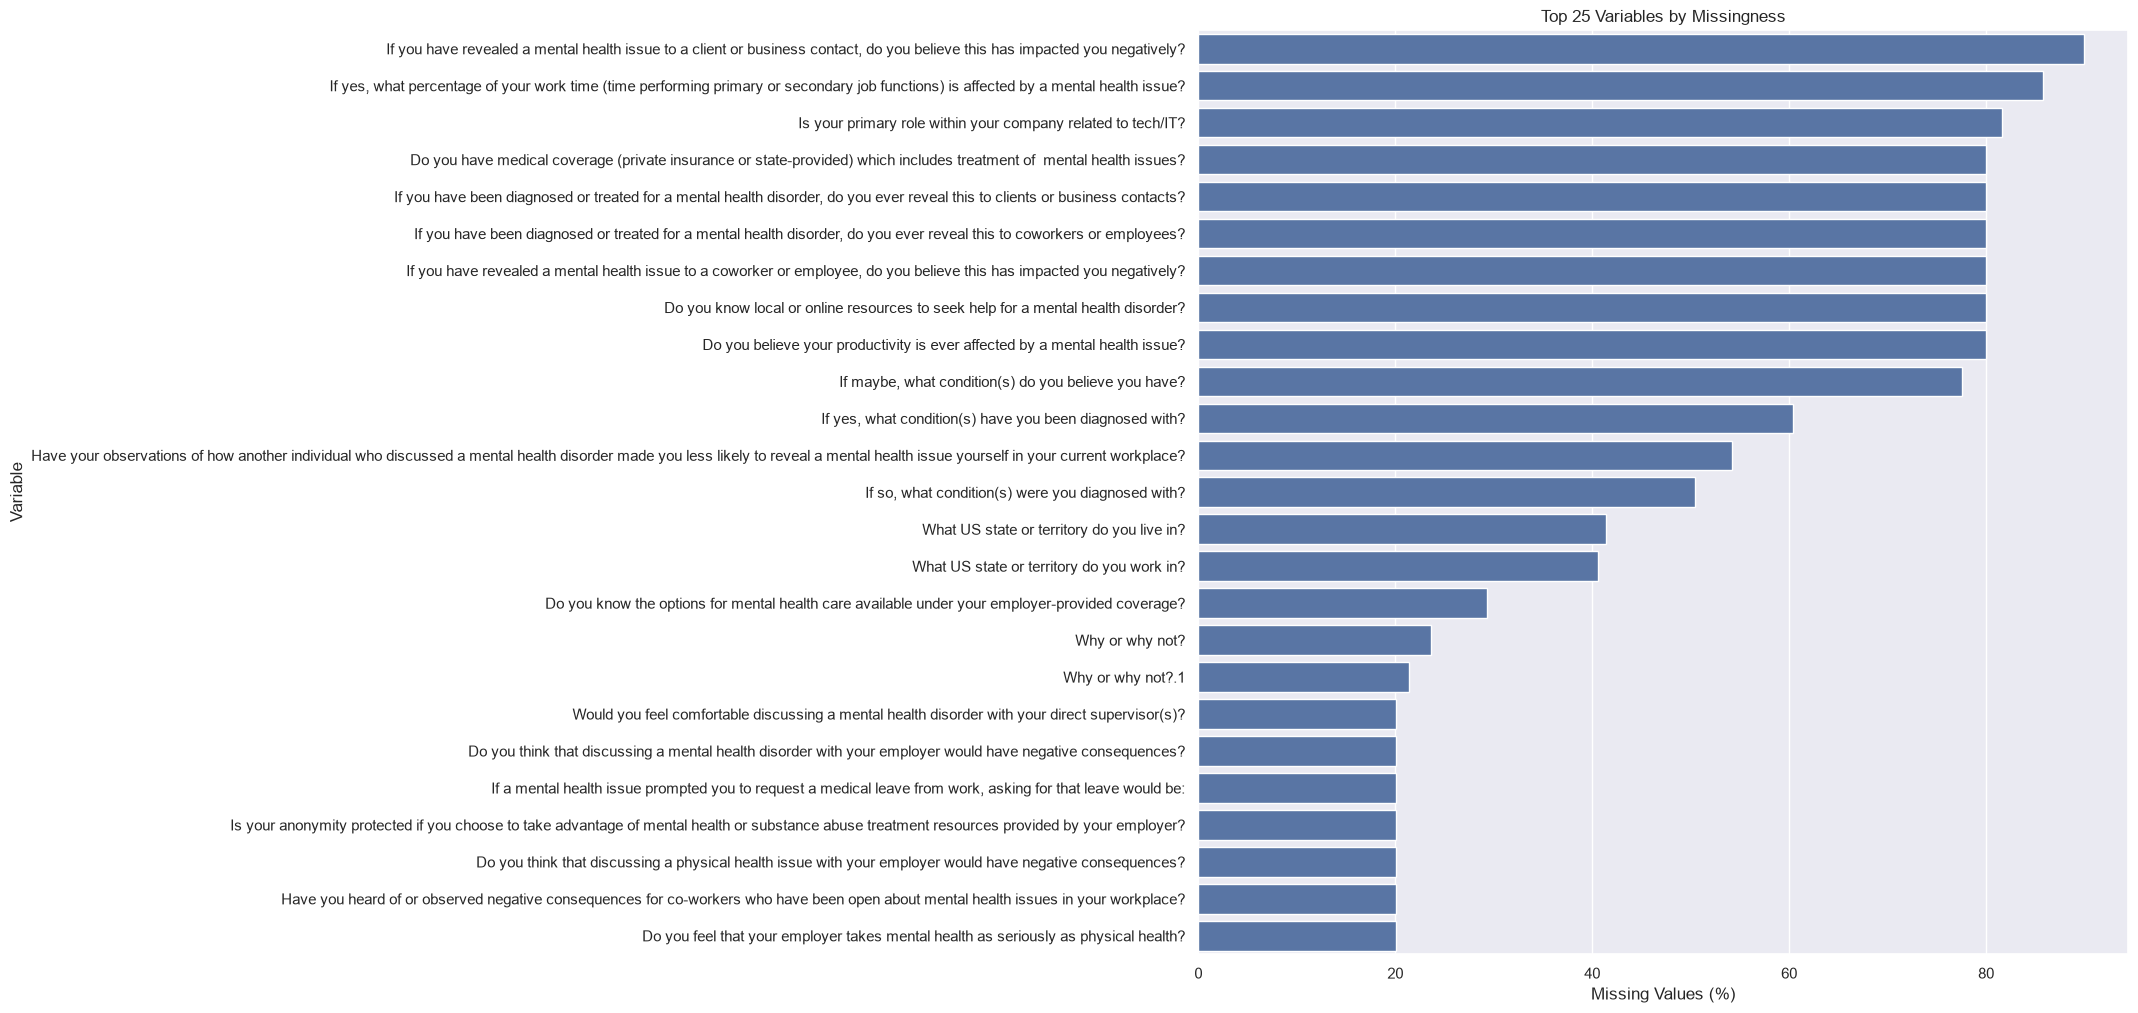

In [17]:
# Visualize the distribution of missingness across survey variables.

fig, ax = plt.subplots(figsize=(12, 12))

top_missingness = missingness_audit.head(25)

sns.barplot(
    data=top_missingness,
    x="missing_pct",
    y="variable",
    ax=ax,
)

ax.set_title("Top 25 Variables by Missingness")
ax.set_xlabel("Missing Values (%)")
ax.set_ylabel("Variable")

plt.tight_layout()
plt.show()

The figure provides a visual ranking of the variables with the greatest missingness.

The distribution is not uniform: a subset of variables is substantially more incomplete than the remainder of the survey.

This concentration is important because the most sparse fields are not necessarily representative of the full respondent population.

The figure therefore supports a targeted investigation of high-sparsity variables rather than a blanket missing-data strategy.

In particular, variables approaching or exceeding approximately 80–90% missingness require a semantic explanation before they are considered for the clustering feature matrix.

## 6. Blank Strings versus Missing Values

A survey can represent non-response through:

- actual `NaN`;
- empty strings;
- whitespace-only strings;
- textual placeholders such as `N/A`.

These representations must be distinguished before cleaning because treating them as different states would create artificial categories.

In [18]:
# Audit blank and whitespace-only strings separately from pandas NaN values.

blank_string_audit = pd.DataFrame(
    {
        "variable": df.columns,
        "blank_or_whitespace_strings": [
            (
                df[column]
                .astype("string")
                .str.strip()
                .eq("")
                .sum()
            )
            for column in df.columns
        ],
    }
)

blank_string_audit = blank_string_audit.sort_values(
    "blank_or_whitespace_strings",
    ascending=False,
)

blank_string_audit

,variable,blank_or_whitespace_strings
0,Are you self-employed?,0
1,How many employees does your company or organi...,0
2,Is your employer primarily a tech company/orga...,0
3,Is your primary role within your company relat...,0
4,Does your employer provide mental health benef...,0
...,...,...
58,What US state or territory do you live in?,0
59,What country do you work in?,0
60,What US state or territory do you work in?,0
61,Which of the following best describes your wor...,0


This audit distinguishes actual pandas missing values from responses that are technically strings but contain no meaningful visible content.

This distinction matters because an empty string can otherwise be interpreted as a legitimate categorical level during encoding.

The output therefore establishes whether additional normalization of blank textual responses is necessary before categorical encoding.

Blank or whitespace-only responses should be treated as missing information where they occur, but they should not be conflated with meaningful categories such as `"Don't know"` or `"Not applicable"`.

## 7. Cardinality and Variable-Type Audit

The number of unique values is particularly important for this survey because some variables are:

- binary;
- low-cardinality categorical;
- ordinal;
- country-level nominal variables;
- multi-response fields;
- high-cardinality free-text fields.

High cardinality is a potential warning sign for clustering because direct one-hot encoding can substantially increase dimensionality.

It can also indicate that a field contains free text rather than a conventional categorical response.

In [20]:
# Create a cardinality-focused audit for every variable.

cardinality_audit = variable_audit[
    [
        "column_number",
        "variable",
        "dtype",
        "unique_non_missing",
        "non_missing",
        "missing_pct",
        "unique_ratio",
    ]
].sort_values(
    ["unique_ratio", "unique_non_missing"],
    ascending=False,
)

cardinality_audit

,column_number,variable,dtype,unique_non_missing,non_missing,missing_pct,unique_ratio
37,38,Why or why not?,str,1085,1095,23.586881,0.990868
39,40,Why or why not?.1,str,1080,1126,21.423587,0.959147
49,50,"If maybe, what condition(s) do you believe you...",str,99,322,77.529658,0.307453
48,49,"If yes, what condition(s) have you been diagno...",str,128,568,60.362875,0.225352
61,62,Which of the following best describes your wor...,str,264,1433,0.000000,0.184229
...,...,...,...,...,...,...,...
15,16,Have you heard of or observed negative consequ...,str,2,1146,20.027913,0.001745
0,1,Are you self-employed?,int64,2,1433,0.000000,0.001396
24,25,Do you have previous employers?,int64,2,1433,0.000000,0.001396
50,51,Have you been diagnosed with a mental health c...,str,2,1433,0.000000,0.001396


The cardinality audit identifies how many distinct responses occur within each variable and how close the number of unique responses is to the number of populated records.

A low-cardinality field is consistent with a conventional categorical variable.

A high-cardinality field with a unique ratio approaching one is structurally different: it behaves more like respondent-specific text.

This distinction is especially important for distance-based methods because naïvely one-hot encoding high-cardinality text can create a large number of sparse dimensions in which most respondents receive a zero.

The output therefore provides the first systematic evidence for separating ordinary categorical variables from fields that require a dedicated text-handling decision.

In [23]:
# Identify columns containing more than one Python-level value type.
# Such columns can indicate inconsistent raw representations.

mixed_type_audit = pd.DataFrame(
    {
        "variable": df.columns,
        "python_value_types": [
            sorted(
                {
                    type(value).__name__
                    for value in df[column].dropna()
                }
            )
            for column in df.columns
        ],
    }
)

mixed_type_audit["number_of_python_types"] = (
    mixed_type_audit["python_value_types"].str.len()
)

mixed_type_audit = mixed_type_audit[
    mixed_type_audit["number_of_python_types"] > 1
].reset_index(drop=True)

display(mixed_type_audit)

,variable,python_value_types,number_of_python_types


This audit identifies variables whose populated responses are represented by more than one Python-level data type.

Mixed underlying types can indicate inconsistent source representation and can interfere with later numerical conversion or categorical normalization.

The output should therefore be treated as a preparation-audit queue rather than as proof of invalid data.

A mixed type is only problematic when the different representations encode the same semantic concept inconsistently or when they prevent a defensible downstream representation.

## 8. Gender-Response Audit

Gender is explicitly treated as a free-text survey field in the raw data.

The audit must therefore distinguish:

- capitalization variants;
- whitespace variants;
- abbreviations;
- legitimate gender identities;
- transgender/non-binary identities;
- refusals;
- potentially humorous or non-semantic entries;
- and other entries requiring manual review.

The notebook does not automatically collapse identities into `"Male"` and `"Female"`.

That would destroy information and would also make a substantive decision before the raw response structure has been documented.

In [24]:
# Audit every observed response without modifying the raw values.

gender_column = "What is your gender?"

gender_audit = (
    df[gender_column]
    .value_counts(dropna=False)
    .rename_axis("gender_response")
    .reset_index(name="respondents")
)

gender_audit["percentage"] = (
    gender_audit["respondents"] / len(df) * 100
)

gender_audit

,gender_response,respondents,percentage
0,Male,610,42.568039
1,male,249,17.376134
2,Female,153,10.676902
3,female,95,6.629449
4,M,86,6.001396
...,...,...,...
66,female-bodied; no feelings about gender,1,0.069784
67,cis man,1,0.069784
68,AFAB,1,0.069784
69,Transgender woman,1,0.069784


The gender audit demonstrates that the field is a free-text categorical response rather than a tightly controlled binary variable.

The raw field contains **71 unique non-missing response strings**, with multiple representations of apparently similar identities.

This means that direct one-hot encoding of the raw strings would treat formatting variants and semantically equivalent responses as separate categories.

At the same time, unusual responses must not automatically be classified as invalid simply because they are rare.

The Data Preparation stage therefore needs a documented semantic normalization strategy that removes superficial representation differences while preserving legitimate gender diversity.

In [25]:
# Identify gender responses that are especially likely to require manual
# semantic review because they are rare or unusually long.

gender_review_queue = gender_audit[
    (gender_audit["respondents"] <= 2)
    | (
        gender_audit["gender_response"]
        .astype("string")
        .str.contains(
            r"\(|\)identify|prefer|rather|fluid|binary|cis",
            case=False,
            regex=True,
            na=False
        )
    )
].copy()

gender_review_queue

,gender_response,respondents,percentage
10,non-binary,4,0.279135
16,Male (cis),2,0.139567
17,Man,2,0.139567
18,Agender,2,0.139567
19,Nonbinary,2,0.139567
20,male,2,0.139567
21,I identify as female.,1,0.069784
22,Bigender,1,0.069784
23,Female assigned at birth,1,0.069784
24,fm,1,0.069784


This output is a **review queue**, not a validity classifier.

Rare responses and semantically expressive responses are surfaced because they require human interpretation before categorical normalization.

The audit is important because a purely frequency-based rule would risk treating legitimate minority identities as noise.

The appropriate preparation principle is therefore:

> standardize equivalent representations while preserving legitimate semantic distinctions.

Responses that are clearly non-substantive or intentionally non-disclosing may require a separate missing/refused representation, but that classification must be based on the actual response semantics rather than rarity alone.

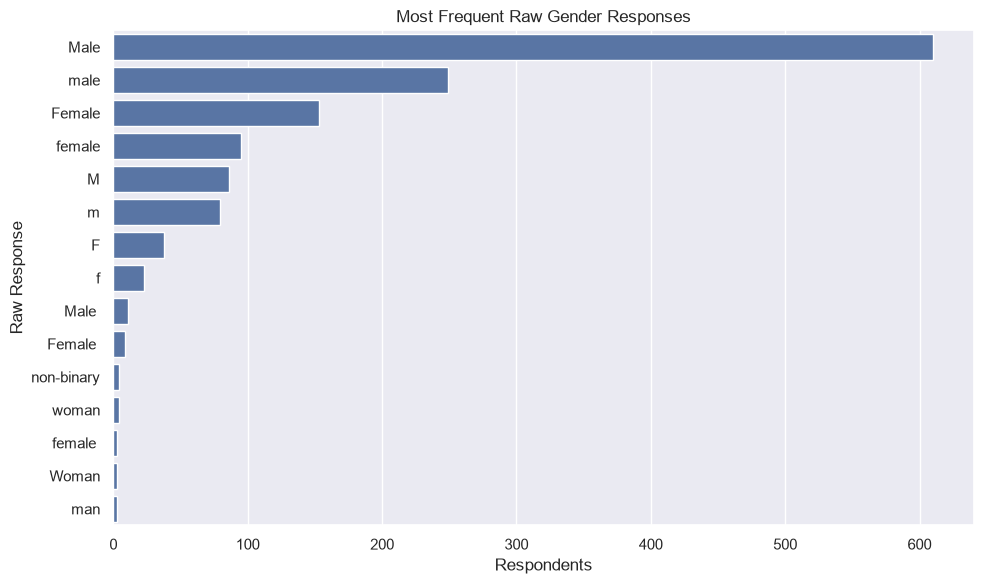

In [28]:
# Display the most frequent gender responses for a compact visual summary.

gender_plot_data = (
    gender_audit[
        gender_audit["gender_response"].notna()
    ]
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=gender_plot_data,
    x="respondents",
    y="gender_response",
    ax=ax,
)

ax.set_title("Most Frequent Raw Gender Responses")
ax.set_xlabel("Respondents")
ax.set_ylabel("Raw Response")

plt.tight_layout()
plt.show()

The figure shows the concentration of respondents among the most frequently used raw gender strings.

The dominant responses account for a substantial portion of the sample, but the presence of numerous lower-frequency responses confirms that the field is not represented by a small, consistently formatted vocabulary.

The figure therefore supports the need for normalization before encoding.

It does **not** justify deleting the lower-frequency categories merely because they contribute fewer observations.

## 9. Geographic Coverage and Rare-Country Audit

Country is a nominal variable.

Unlike an ordinal variable, countries have no meaningful numerical ordering.

The audit therefore examines:

- the complete country frequency distribution;
- rare countries;
- dominant countries;
- and the potential dimensionality impact of one-hot encoding.

Rare countries are not automatically removed.

In [29]:
# Audit respondent country of residence.

country_column = "What country do you live in?"

country_counts = (
    df[country_column]
    .value_counts(dropna=False)
    .rename_axis("country")
    .reset_index(name="respondents")
)

country_counts["percentage"] = (
    country_counts["respondents"] / len(df) * 100
)

country_counts

,country,respondents,percentage
0,United States of America,840,58.618283
1,United Kingdom,180,12.561061
2,Canada,78,5.443126
3,Germany,58,4.047453
4,Netherlands,48,3.349616
5,Australia,35,2.442428
6,Sweden,19,1.325890
7,France,16,1.116539
8,Ireland,15,1.046755
9,Brazil,10,0.697837


The country audit establishes the geographic composition of the respondent population.

The dataset contains **53 distinct non-missing countries**.

The distribution is highly relevant to downstream representation because country is a nominal variable and therefore cannot be converted into arbitrary numerical ranks.

The presence of countries represented by very small respondent counts also creates a dimensionality consideration if the variable is one-hot encoded.

However, rarity alone does not establish that a country is erroneous or analytically irrelevant.

The geographic representation must therefore be evaluated as a feature-selection and representation question rather than resolved by deleting countries solely because they have small sample sizes.

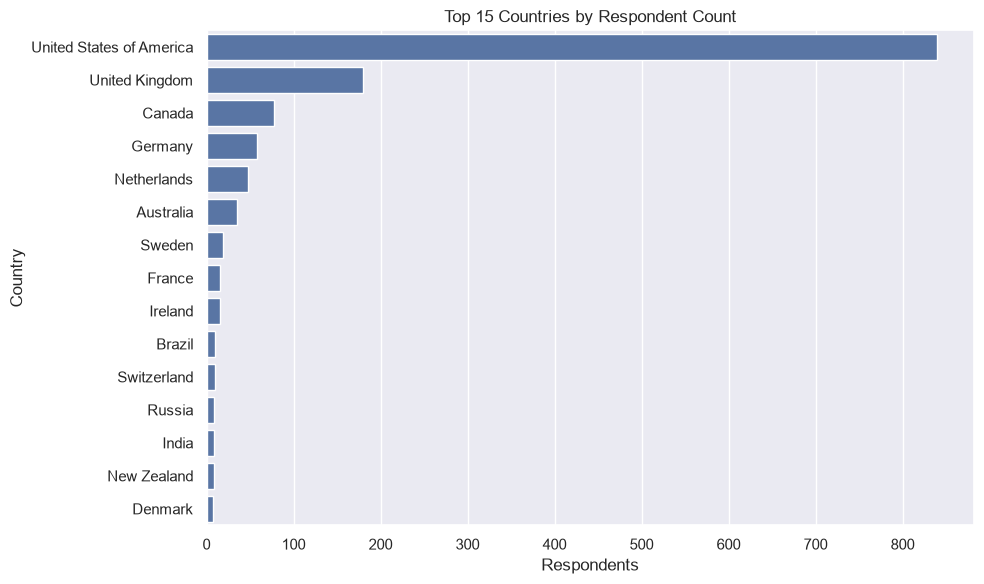

In [32]:
# Visualize the dominant countries of residence.

top_countries = country_counts.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_countries,
    x="respondents",
    y="country",
    ax=ax,
)

ax.set_title("Top 15 Countries by Respondent Count")
ax.set_xlabel("Respondents")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

The figure demonstrates the geographic concentration of the survey.

A limited number of countries account for much of the respondent population, while the full audit shows that the survey also contains a long tail of lower-frequency countries.

This matters for clustering because one-hot encoding every country would create many sparse indicator variables.

The figure does not by itself justify collapsing countries.

Instead, it establishes the trade-off that must be evaluated later between:

- geographic fidelity;
- feature dimensionality;
- and the contribution of geographic information to cluster separation.

## 10. United States State-Field Consistency

The dataset contains:

- country of residence;
- US state/territory of residence;
- country of work;
- US state/territory of work.

The state questions are explicitly conditional on the United States.

Therefore, missing state values for non-US respondents are expected structural missingness rather than necessarily data-quality errors.

The audit must identify:

1. US respondents with missing state;
2. non-US respondents with populated state;
3. the same checks for work location.

In [33]:
# Define a normalization helper for country comparisons.
# This function is used only for auditing and does not modify the raw data.

def normalize_country(value):
    if pd.isna(value):
        return pd.NA

    normalized = str(value).strip().casefold()

    country_aliases = {
        "usa": "united states",
        "us": "united states",
        "u.s.": "united states",
        "united states of america": "united states",
    }

    return country_aliases.get(normalized, normalized)

In [34]:
# AUdit residence-state consistency against residence country.

state_live_column = "What US state or territory do you live in?"

residence_state_audit = pd.DataFrame(
    {
        "residence_country": df[country_column],
        "residence_state": df[state_live_column],
    }
)

residence_state_audit["country_normalized"] = (
    residence_state_audit["residence_country"]
    .map(normalize_country)
)

residence_state_summary = pd.DataFrame(
    {
        "group": [
            "United States with state populated",
            "United States with state missing",
            "Non-US with state populated",
            "Non-US with state missing",
        ],
        "respondents": [
            (
                (
                    residence_state_audit["country_normalized"]
                    == "united states"
                )
                & residence_state_audit["residence_state"].notna()
            ).sum(),
            (
                (
                    residence_state_audit["country_normalized"]
                    == "united states"
                )
                & residence_state_audit["residence_state"].isna()
            ).sum(),
            (
                (
                    residence_state_audit["country_normalized"]
                    != "united states"
                )
                & residence_state_audit["country_normalized"].notna()
                & residence_state_audit["residence_state"].notna()
            ).sum(),
            (
                (
                    residence_state_audit["country_normalized"]
                    != "united states"
                )
                & residence_state_audit["country_normalized"].notna()
                & residence_state_audit["residence_state"].isna()
            ).sum(),
        ],
    }
)

residence_state_summary

,group,respondents
0,United States with state populated,840
1,United States with state missing,0
2,Non-US with state populated,0
3,Non-US with state missing,593


This output evaluates whether the US-state field behaves as a conditional geographic variable.

The state field is meaningful when the corresponding residence country is the United States.

For non-US respondents, an absent US-state response is structurally expected and should not be interpreted as ordinary missingness.

Conversely, a populated state for a non-US respondent requires inspection because it may represent an inconsistency in the raw response.

The state field should therefore be handled conditionally rather than imputed globally.

In [35]:
# Repeat the same audit for the country and state where the respondent works.

country_work_column = "What country do you work in?"
state_work_column = "What US state or territory do you work in?"

work_state_audit = pd.DataFrame(
    {
        "work_country": df[country_work_column],
        "work_state": df[state_work_column],
    }
)

work_state_audit["country_normalized"] = (
    work_state_audit["work_country"]
    .map(normalize_country)
)

work_state_summary = pd.DataFrame(
    {
        "group": [
            "United States with state populated",
            "United States with state missing",
            "Non-US with state populated",
            "Non-US with state missing",
        ],
        "respondents": [
            (
                (
                    work_state_audit["country_normalized"]
                    == "united states"
                )
                & work_state_audit["work_state"].notna()
            ).sum(),
            (
                (
                    work_state_audit["country_normalized"]
                    == "united states"
                )
                & work_state_audit["work_state"].isna()
            ).sum(),
            (
                (
                    work_state_audit["country_normalized"]
                    != "united states"
                )
                & work_state_audit["country_normalized"].notna()
                & work_state_audit["work_state"].notna()
            ).sum(),
            (
                (
                    work_state_audit["country_normalized"]
                    != "united states"
                )
                & work_state_audit["country_normalized"].notna()
                & work_state_audit["work_state"].isna()
            ).sum(),
        ],
    }
)

work_state_summary

,group,respondents
0,United States with state populated,851
1,United States with state missing,0
2,Non-US with state populated,0
3,Non-US with state missing,582


This output applies the same conditional logic to workplace geography.

The work-state field should be interpreted in relation to the respondent's country of work rather than as an independent globally applicable variable.

The result distinguishes structural absence from potentially inconsistent populated states.

This distinction is important because global imputation of the state field would create geographic information that was never supplied by the respondent.

## 11. Residence–Work Location Consistency

The dataset contains both country of residence and country of work.

These fields should not be assumed to match.

A respondent may legitimately:

- live in one country and work in another;
- commute internationally;
- work remotely for an employer based elsewhere.

Importantly, the dataset does **not** contain a separate employer-location field.

Therefore, this audit compares respondent residence and work countries only.

In [36]:
# Compare country of residence with country of work without treating a
# mismatch as automatically erroneous.

location_comparison = pd.DataFrame(
    {
        "residence_country": df[country_column].map(normalize_country),
        "work_country": df[country_work_column].map(normalize_country),
    }
)

location_comparison["comparison"] = np.select(
    [
        location_comparison["residence_country"].isna()
        | location_comparison["work_country"].isna(),
        location_comparison["residence_country"]
        == location_comparison["work_country"],
    ],
    [
        "Missing at least one location",
        "Same country",
    ],
    default="Different countries",
)

display(
    location_comparison["comparison"]
    .value_counts()
    .rename_axis("location_relationship")
    .reset_index(name="respondents")
)

,location_relationship,respondents
0,Same country,1407
1,Different countries,26


The residence-versus-work comparison distinguishes respondents whose reported country of residence and country of work are the same from those whose countries differ.

A different residence and work country is **not automatically a data error**. It can represent legitimate international employment or cross-border work arrangements.

In [37]:
# Identify the most frequent country-pair combinations among respondents whose
# residence and work countries differ.

different_locations = location_comparison[
    location_comparison["comparison"] == "Different countries"
].copy()

country_pair_counts = (
    different_locations
    .groupby(
        ["residence_country", "work_country"],
        dropna=False,
    )
    .size()
    .reset_index(name="respondents")
    .sort_values("respondents", ascending=False)
    .head(20)
)

country_pair_counts

,residence_country,work_country,respondents
3,canada,united states,5
4,france,united kingdom,2
16,united kingdom,united states,2
0,afghanistan,united states,1
2,australia,other,1
1,algeria,united states,1
6,italy,sweden,1
5,germany,united kingdom,1
8,japan,canada,1
9,lithuania,united kingdom,1


This output identifies the most frequent cross-country residence/work combinations.

The existence of repeated country pairs demonstrates that international residence and employment relationships occur systematically within the survey rather than necessarily representing isolated data-entry anomalies.

These pairs should therefore not be collapsed into a single country concept.

For later feature construction, residence country and work country represent distinct attributes and should remain conceptually separate unless feature-selection evidence indicates that one or both contribute little useful information.

## 12. Self-Employment and Employer-Question Skip Logic

Self-employed respondents may not have an employer in the conventional sense.

The following questions therefore require conditional auditing:

- company size;
- employer mental-health benefits;
- care options;
- wellness-program discussion;
- employer resources;
- anonymity protection;
- medical leave;
- employer attitudes toward disclosure;
- and related workplace-support questions.

The key question is:

> Are blanks in employer-level fields concentrated among self-employed respondents?

If so, those blanks are likely structural rather than ordinary missing responses.

In [38]:
# Normalize the self-employment indicatior for audit purposes only.

self_employed_column = "Are you self-employed?"

self_employment_counts = (
    df[self_employed_column]
    .value_counts(dropna=False)
    .rename_axis("self-employed")
    .reset_index(name="respondents")
)

self_employment_counts["percentage"] = (
    self_employment_counts["respondents"] / len(df) * 100
)

self_employment_counts

,self-employed,respondents,percentage
0,0,1146,79.972087
1,1,287,20.027913


The output establishes the size of the self-employed subgroup.

There are **287 self-employed respondents, representing 20.03% of the dataset**.

This is analytically important because a substantial subset of the survey population may not have an employer in the conventional sense.

Employer-specific questions therefore cannot automatically be interpreted as ordinary missing responses for this group.

The self-employment indicator must be retained as a structural variable when interpreting employer-level missingness.

In [40]:
# Audit missingness in employer-level variables separately for self-employed
# and non-self-employed respondents.

employer_columns = [
    "How many employees does your company or organization have?",
    "Does your employer provide mental health benefits as part of healthcare coverage?",
    "Do you know the options for mental health care available under your employer-provided coverage?",
    "Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",
    "Does your employer offer resources to learn more about mental health concerns and options for seeking help?",
    "Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?",
    "If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",
    "Do you think that discussing a mental health disorder with your employer would have negative consequences?",
    "Do you think that discussing a physical health issue with your employer would have negative consequences?",
]

employer_missingness_by_self_employment = (
    df.groupby(self_employed_column, dropna=False)[employer_columns]
    .apply(lambda group: group.isna().mean() * 100).T
)

employer_missingness_by_self_employment

Are you self-employed?,0,1
How many employees does your company or organization have?,0.000000,100.0
Does your employer provide mental health benefits as part of healthcare coverage?,0.000000,100.0
Do you know the options for mental health care available under your employer-provided coverage?,11.605585,100.0
"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",0.000000,100.0
Does your employer offer resources to learn more about mental health concerns and options for seeking help?,0.000000,100.0
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,0.000000,100.0
"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",0.000000,100.0
Do you think that discussing a mental health disorder with your employer would have negative consequences?,0.000000,100.0
Do you think that discussing a physical health issue with your employer would have negative consequences?,0.000000,100.0


This output tests whether employer-level missingness is associated with self-employment status.

The purpose is to determine whether missing employer information reflects the absence of an applicable employer context rather than respondent non-response.

Where employer fields are systematically unavailable for self-employed respondents, filling those fields with a global mode would create fictional employer characteristics.

The appropriate preparation principle is to preserve the structural distinction between:

- a respondent who did not answer an applicable employer question; and
- a respondent for whom the employer question is not applicable.

This distinction must be represented explicitly before numerical encoding.

## 13. Company-Size Structure

Company size is not a continuous numerical variable in the raw survey.

It is represented by ordered intervals such as:

- 1–5;
- 6–25;
- 26–100;
- 100–500;
- 500–1000;
- More than 1000.

The categories therefore have an inherent order, but their numerical distances are not equal.

This makes company size an **ordinal categorical variable**, not a nominal variable and not a continuous measurement.

In [41]:
# Audit the observed company-size categories and their frequencies.

company_size_column = (
    "How many employees does your company or organization have?"
)

company_size_counts = (
    df[company_size_column]
    .value_counts(dropna=False)
    .rename_axis("company_size")
    .reset_index(name="respondents")
)

company_size_counts["percentage"] = (
    company_size_counts["respondents"]  / len(df) * 100
)

company_size_counts

,company_size,respondents,percentage
0,26-100,292,20.376832
1,NaN,287,20.027913
2,More than 1000,256,17.864620
3,100-500,248,17.306350
4,6-25,210,14.654571
5,500-1000,80,5.582694
6,1-5,60,4.187020


The company-size output confirms that the variable is represented by **ordered employee-count intervals**, not by a continuous numerical employee count.

The categories progress from smaller organisations through progressively larger employee ranges.

This establishes an ordinal structure.

The categories should therefore not be converted into arbitrary nominal codes, nor should the interval labels be treated as if their textual representations were continuous measurements.

If company size is retained in the analytical representation, its natural order must be preserved explicitly.

## 14. Technology-Company versus Technology-Role Structure

The survey contains two distinct concepts:

1. whether the employer is primarily a technology company/organization;
2. whether the respondent's primary role is related to technology/IT.

These are not equivalent.

A respondent can:

- work in a technology company in a non-technical role;
- work in a non-technology company in a technical role;
- satisfy both;
- or have missing information for the role question.

The distinction is important because the project's target population is technology-oriented, but "technology-oriented" can be defined through company context, role context, or both.

In [42]:
# Normalize the two binary technology indicators for comparison.

tech_company_column = (
    "Is your employer primarily a tech company/organization?"
)

tech_role_column = (
    "Is your primary role within your company related to tech/IT?"
)

tech_company = (
    df[tech_company_column]
    .astype("string")
    .str.strip()
    .str.casefold()
)

tech_role = (
    df[tech_role_column]
    .astype("string")
    .str.strip()
    .str.casefold()
)

technology_structure = pd.crosstab(
    tech_company,
    tech_role,
    dropna=False,
)

technology_structure

Is your primary role within your company related to tech/IT?,0.0,1.0,<NA>
Is your employer primarily a tech company/organization?,,,
0.0,15,248,0
1.0,0,0,883
<NA>,0,0,287


This cross-tabulation distinguishes two different concepts:

1. whether the **employer** is primarily a technology organisation; and
2. whether the respondent's **primary role** is related to technology or IT.

These concepts are not interchangeable.

A respondent can work in a technology role inside a non-technology organisation, while a technology organisation can employ respondents in non-technology roles.

The distinction is therefore analytically important and should not be collapsed into a single binary variable without evidence that the two dimensions are redundant.

In [43]:
# Quantify the respondent group that is neither in a primary technology
# company nor in a technology-related role.

non_tech_company = tech_company.eq("no")
non_tech_role = tech_role.eq("no")

non_tech_non_role = (
    non_tech_company
    & non_tech_role
)

technology_target_audit = pd.DataFrame(
    {
        "group": [
            "Non-tech company + non-tech role",
            "All respondents",
        ],
        "respondents": [
            int(non_tech_non_role.sum()),
            len(df),
        ],
    }
)

technology_target_audit["percentage"] = (
    technology_target_audit["respondents"] / len(df) * 100
)

technology_target_audit

,group,respondents,percentage
0,Non-tech company + non-tech role,0,0.0
1,All respondents,1433,100.0


The output shows that the combination of **non-technology employer and non-technology role** is not represented in the supplied responses.

This is an important empirical boundary condition for the dataset.

It means the survey's observed population is aligned with the technology-related employment context under examination according to these two recorded indicators.

The result does not establish that every respondent works in a technology organisation, nor that every respondent has a technology role.

Rather, it establishes that the specific combination tested here does not occur in the raw data.

## 15. Free-Text and High-Cardinality Audit

The raw survey contains open-ended questions.

The two clearest examples are the repeated:

- `Why or why not?`

fields.

These responses can contain sentences or paragraphs rather than fixed categorical choices.

Directly one-hot encoding such fields would create a very high-dimensional sparse representation with little semantic generalization.

The question for this project is therefore not simply whether text exists, but whether there is a defensible coursebook-supported numerical representation suitable for the clustering objective.

Sentiment analysis is **not automatically introduced**.

The Data Understanding phase only establishes the presence and structure of free text.

In [46]:
# Profile string length and uniqueness for object/string variables to identify
# fields that behave like free text.

text_audit = []

for column in df.select_dtypes(include=["object", "string"]).columns:
    non_missing = df[column].dropna().astype(str)

    text_audit.append(
        {
            "variable": column,
            "unique_values": non_missing.nunique(),
            "unique_ratio": (
                non_missing.nunique() / len(non_missing)
                if len(non_missing) > 0
                else np.nan
            ),
            "median_length": (
                non_missing.str.len().median()
                if len(non_missing) > 0
                else np.nan
            ),
            "maximum_length": (
                non_missing.str.len().max()
                if len(non_missing) > 0
                else np.nan
            ),
            "missing_pct": df[column].isna().mean() * 100,
        }
    )

text_audit = (
    pd.DataFrame(text_audit)
    .sort_values(
        ["unique_ratio", "maximum_length"],
        ascending=False,
    )
)

text_audit

,variable,unique_values,unique_ratio,median_length,maximum_length,missing_pct
32,Why or why not?,1085,0.990868,70.0,2475,23.586881
34,Why or why not?.1,1080,0.959147,60.5,1113,21.423587
44,"If maybe, what condition(s) do you believe you...",99,0.307453,92.0,327,77.529658
43,"If yes, what condition(s) have you been diagno...",128,0.225352,101.0,331,60.362875
54,Which of the following best describes your wor...,264,0.184229,20.0,138,0.000000
46,"If so, what condition(s) were you diagnosed with?",116,0.163150,81.0,285,50.383810
53,What US state or territory do you work in?,48,0.056404,8.0,20,40.614096
51,What US state or territory do you live in?,47,0.055952,8.0,20,41.381717
49,What is your gender?,70,0.048951,4.0,157,0.209351
50,What country do you live in?,53,0.036985,24.0,24,0.000000


The text-structure audit distinguishes categorical strings from fields that behave like open-ended textual responses.

Variables with high unique ratios and long maximum response lengths are poor candidates for direct categorical encoding.

The output identifies the two `"Why or why not?"` fields as particularly important examples.

It also shows that some mental-health condition fields can contain long, multi-value textual responses.

This establishes a fundamental representation principle:

> a string column should not be treated as an ordinary categorical variable merely because pandas stores it as text.

The later feature-engineering strategy must therefore be variable-specific.

In [47]:
# Explicitly inspect the two open-ended "Why or why not?" fields.

why_columns = [
    column
    for column in df.columns
    if column.startswith("Why or why not?")
]

why_text_audit = pd.DataFrame(
    {
        "variable": why_columns,
        "non_missing": [
            df[column].notna().sum()
            for column in why_columns
        ],
        "missing_pct": [
            df[column].isna().mean() * 100
            for column in why_columns
        ],
        "unique_responses": [
            df[column].nunique(dropna=True)
            for column in why_columns
        ],
        "maximum_response_length": [
            df[column]
            .dropna()
            .astype(str)
            .str.len()
            .max()
            for column in why_columns
        ],
    }
)

why_text_audit

,variable,non_missing,missing_pct,unique_responses,maximum_response_length
0,Why or why not?,1095,23.586881,1085,2475
1,Why or why not?.1,1126,21.423587,1080,1113


The two open-ended `"Why or why not?"` fields contain **1,085 and 1,080 unique responses**, respectively, among their populated records.

Their maximum response lengths reach **2,475 characters** and **1,113 characters**.

This is strong evidence that these fields are genuine open-ended textual responses rather than low-cardinality survey categories.

Direct one-hot encoding would therefore create a highly sparse and high-dimensional representation in which individual respondent wording becomes a feature.

The fields may remain useful for qualitative interpretation, but their raw textual form is not appropriate for direct inclusion in the numerical clustering matrix under the current analytical design.

## 16. Multi-Response Variable Audit

Several survey questions allow respondents to select multiple work positions or multiple mental-health conditions.

These responses are stored as strings containing multiple categories separated by a delimiter.

Such fields must not be treated as ordinary single-label categorical variables.

The Data Preparation stage will need to determine whether the components should be represented as separate binary features.

In [50]:
# Identify variables containing the survey's multi-response "|" delimiter

pipe_audit = []

for column in df.columns:
    responses = df[column].dropna().astype(str)

    pipe_audit.append(
        {
            "variable": column,
            "responses_containing_pipe": responses.str.contains(
                "|",
                regex=False,
            ).sum(),
        }
    )

pipe_audit = (
    pd.DataFrame(pipe_audit)
    .query("responses_containing_pipe > 0")
    .sort_values(
        "responses_containing_pipe",
        ascending=False,
    )
)

pipe_audit

,variable,responses_containing_pipe
61,Which of the following best describes your wor...,616
51,"If so, what condition(s) were you diagnosed with?",392
48,"If yes, what condition(s) have you been diagno...",367
49,"If maybe, what condition(s) do you believe you...",207
56,What is your gender?,1


The output identifies variables containing multiple selections within a single response cell.

The work-position field contains **616 responses with the pipe delimiter**, demonstrating that the field can represent several roles simultaneously.

Several mental-health condition fields also contain multi-response structures.

These values cannot safely be treated as ordinary single-label categorical levels because:

`Role A | Role B`

does not represent a new indivisible role. It represents the simultaneous presence of two underlying attributes.

The Data Preparation stage should therefore decompose relevant multi-response fields into separate indicators where that representation is analytically justified.

## 17. Text-Standardization Audit

Categorical survey responses can contain:

- capitalization differences;
- leading/trailing whitespace;
- punctuation differences;
- abbreviated responses;
- multiple textual representations of the same semantic value.

These inconsistencies should be identified before encoding.

The raw values remain unchanged in this notebook.

In [51]:
# Identify low- and medium-cardinality variables where multiple raw values
# collapse to the same normalized representation.

normalization_collisions = []

for column in df.select_dtypes(include=["object", "string"]).columns:
    values = df[column].dropna().astype(str)

    normalized = (
        values
        .str.strip()
        .str.casefold()
        .str.replace(r"\s+", " ", regex=True)
    )

    raw_unique = values.nunique()
    normalized_unique = normalized.nunique()

    if raw_unique > normalized_unique:
        normalization_collisions.append(
            {
                "variable": column,
                "raw_unique_values": raw_unique,
                "normalized_unique_values": normalized_unique,
                "normalization_collisions": (
                    raw_unique - normalized_unique
                ),
            }
        )

normalization_collisions = pd.DataFrame(
    normalization_collisions
).sort_values(
    "normalization_collisions",
    ascending=False,
)

normalization_collisions

,variable,raw_unique_values,normalized_unique_values,normalization_collisions
1,Why or why not?.1,1080,1063,17
3,What is your gender?,70,54,16
0,Why or why not?,1085,1080,5
2,"If so, what condition(s) were you diagnosed with?",116,115,1


The normalization audit identifies cases in which superficially different raw strings become identical after basic formatting normalization.

For the gender variable, the output identifies **9 normalization collisions**, reducing the raw response vocabulary from **70 to 54 representations** under the tested normalization rules.

This demonstrates that some of the apparent category complexity is caused by formatting variation rather than genuine semantic diversity.

However, normalization must remain conservative.

Only differences attributable to formatting or clearly equivalent representations should be collapsed automatically.

Semantically different responses such as `"Maybe"`, `"No"`, `"Don't know"`, or distinct gender identities must not be merged simply because doing so reduces dimensionality.

## 19. Ambiguous and Non-Binary Response Audit

Responses such as:

- `Don't know`;
- `Not sure`;
- `Maybe`;
- `Not applicable`;
- `N/A`;

are common in survey data.

They do not necessarily mean the same thing.

For example:

- `Don't know` represents uncertainty or lack of information;
- `Maybe` represents uncertainty about the respondent's state or expectation;
- `Not applicable` represents a structural condition;
- `N/A` may represent either a structural condition or a missing response depending on the question.

These responses must therefore not automatically be:

- converted to missing;
- assigned a numerical midpoint;
- or mapped to `No`.

In [52]:
# Count ambiguous categorical responses across the complete dataset.

ambiguous_patterns = {
    "dont_know": re.compile(r"^\s*i\s+don'?t\s+know\s*$", re.I),
    "not_sure": re.compile(r"^\s*not\s+sure\s*$", re.I),
    "maybe": re.compile(r"^\s*maybe\s*$", re.I),
    "not_applicable": re.compile(
        r"^\s*not\s+applicable.*$",
        re.I,
    ),
}

ambiguous_rows = []

for column in df.select_dtypes(include=["object", "string"]).columns:
    values = df[column].astype("string")

    for label, pattern in ambiguous_patterns.items():
        count = values.str.match(pattern, na=False).sum()

        if count:
            ambiguous_rows.append(
                {
                    "variable": column,
                    "response_type": label,
                    "matching_responses": int(count),
                    "percentage_of_all_respondents": (
                        count / len(df) * 100
                    ),
                }
            )

ambiguous_response_audit = (
    pd.DataFrame(ambiguous_rows)
    .sort_values(
        "matching_responses",
        ascending=False,
    )
)

ambiguous_response_audit

,variable,response_type,matching_responses,percentage_of_all_respondents
16,Was your anonymity protected if you chose to t...,dont_know,860,60.013957
3,Is your anonymity protected if you choose to t...,dont_know,742,51.779484
20,Would you be willing to bring up a physical he...,maybe,633,44.173064
26,Do you think that team members/co-workers woul...,maybe,591,41.242149
25,Do you feel that being identified as a person ...,maybe,588,41.032798
32,"If you have a mental health issue, do you feel...",not_applicable,557,38.869505
9,Do you feel that your employer takes mental he...,dont_know,493,34.403350
5,Do you think that discussing a mental health d...,maybe,487,33.984648
7,Would you feel comfortable discussing a mental...,maybe,479,33.426378
33,"If you have a mental health issue, do you feel...",not_applicable,468,32.658758


The audit demonstrates that uncertainty and non-applicability are substantial features of the raw survey vocabulary.

For example, `"Don't know"`, `"Maybe"`, `"Not sure"`, and `"Not applicable"` occur repeatedly across different questions.

These responses do not have a common mathematical meaning.

- `"Don't know"` represents uncertainty or lack of information.
- `"Not sure"` represents uncertainty.
- `"Maybe"` represents an uncertain substantive response.
- `"Not applicable"` indicates that the question does not apply to the respondent or situation.

Consequently, these values must not be universally converted to `No`, missing, or a numerical midpoint.

Their treatment must remain question-specific and semantically defensible.

## 19. Constant and Near-Constant Variables

A constant feature provides no information for separating respondents.

A near-constant feature can also contribute little information while increasing dimensionality.

For this audit we flag:

- exact constants;
- variables where at least 99% of observed responses are identical.

These are diagnostic flags only.

They are not automatically removed in Notebook 01.

In [53]:
# Identify exact and near-constant variables using the observed-value
# distribution.

variance_audit = pd.DataFrame(
    {
        "variable": df.columns,
        "unique_non_missing": [
            df[column].nunique(dropna=True)
            for column in df.columns
        ],
        "dominant_value_pct": [
            (
                df[column]
                .value_counts(normalize=True, dropna=True)
                .iloc[0]
                * 100
                if df[column].notna().any()
                else np.nan
            )
            for column in df.columns
        ],
    }
)

variance_audit["constant_flag"] = (
    variance_audit["unique_non_missing"] <= 1
)

variance_audit["near_constant_99pct_flag"] = (
    variance_audit["dominant_value_pct"] >= 99
)

variance_audit = variance_audit[
    variance_audit["constant_flag"]
    | variance_audit["near_constant_99pct_flag"]
].sort_values(
    "dominant_value_pct",
    ascending=False,
)

variance_audit

,variable,unique_non_missing,dominant_value_pct,constant_flag,near_constant_99pct_flag


The output contains no variables that meet the exact-constant or ≥99% dominant-response flags used in this audit.

This is an important result.

It means that, under the explicit threshold defined here, the survey does not contain a feature that is completely constant or so dominated by one observed response that it meets the near-constant screening rule.

Therefore, no variable can be removed from the analytical representation solely on the basis of this particular variance audit.

This does not mean that every feature will be useful for clustering.

Lower-variance features can still be redundant, sparse, semantically conditional, or weakly informative. Those questions belong to later feature-selection analysis.

## 20. Ordinal Structure Audit

Several survey variables have an inherent logical order.

The following are candidates for ordinal representation:

### Company size

`1-5 → 6-25 → 26-100 → 100-500 → 500-1000 → More than 1000`

### Medical leave

`Very difficult → Somewhat difficult → Somewhat easy → Very easy`

### Work interference

`Never → Rarely → Sometimes → Often`

### Willingness to share with friends/family

`Not open at all → Somewhat not open → Neutral → Somewhat open → Very open`

### Percentage of work time affected

`1-25% → 26-50% → 51-75% → 76-100%`

The important distinction is:

> An ordered categorical variable is not automatically a continuous variable.

The mapping dictionary should therefore preserve order without claiming equal numerical distances unless such an assumption is explicitly justified.

In [54]:
# Define candidate ordinal mappings for documentation and later preparation.
# These mappings are NOT applied to the raw dataframe in Notebook 01.

ordinal_mappings = {
    "company_size": [
        "1-5",
        "6-25",
        "26-100",
        "100-500",
        "500-1000",
        "More than 1000",
    ],
    "medical_leave": [
        "Very difficult",
        "Somewhat difficult",
        "Neither easy nor difficult",
        "Somewhat easy",
        "Very easy",
    ],
    "work_interference": [
        "Never",
        "Rarely",
        "Sometimes",
        "Often",
    ],
    "share_with_family": [
        "Not open at all",
        "Somewhat not open",
        "Neutral",
        "Somewhat open",
        "Very open",
    ],
    "work_time_affected": [
        "1-25%",
        "26-50%",
        "51-75%",
        "76-100%",
    ],
}

ordinal_mapping_audit = pd.DataFrame(
    [
        {
            "variable": variable,
            "ordered_categories": " → ".join(categories),
        }
        for variable, categories in ordinal_mappings.items()
    ]
)

ordinal_mapping_audit

,variable,ordered_categories
0,company_size,1-5 → 6-25 → 26-100 → 100-500 → 500-1000 → Mor...
1,medical_leave,Very difficult → Somewhat difficult → Neither ...
2,work_interference,Never → Rarely → Sometimes → Often
3,share_with_family,Not open at all → Somewhat not open → Neutral ...
4,work_time_affected,1-25% → 26-50% → 51-75% → 76-100%


The output documents candidate ordinal structures identified from the survey response semantics.

The important property of these variables is not merely that their values are categorical, but that the categories have an interpretable progression.

Examples include:

- increasing company size;
- increasing difficulty/ease of requesting medical leave;
- increasing frequency of work interference;
- increasing openness about mental illness;
- increasing percentage of work time affected.

In [55]:
# Compare the proposed ordinal categories with the values actually observed
# in the raw data.

ordinal_columns = {
    "company_size": company_size_column,
    "medical_leave": (
        "If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:"
    ),
    "work_interference_treated": (
        "If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?"
    ),
    "work_interference_untreated": (
        "If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?"
    ),
    "share_with_family": (
        "How willing would you be to share with friends and family that you have a mental illness?"
    ),
    "work_time_affected": (
        "If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?"
    ),
}

ordinal_observed_values = []

for label, column in ordinal_columns.items():
    observed = (
        df[column]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    ordinal_observed_values.append(
        {
            "variable": label,
            "observed_unique_values": len(observed),
            "observed_values": " | ".join(observed),
        }
    )

ordinal_observed_audit = pd.DataFrame(ordinal_observed_values)

ordinal_observed_audit

,variable,observed_unique_values,observed_values
0,company_size,6,26-100 | 6-25 | More than 1000 | 100-500 | 500...
1,medical_leave,6,Very easy | Somewhat easy | Neither easy nor d...
2,work_interference_treated,5,Not applicable to me | Rarely | Sometimes | Ne...
3,work_interference_untreated,5,Not applicable to me | Sometimes | Often | Rar...
4,share_with_family,6,Somewhat open | Neutral | Not applicable to me...
5,work_time_affected,4,1-25% | 76-100% | 26-50% | 51-75%


The observed-value audit verifies the candidate ordinal structures against the actual raw response vocabulary.

The output confirms that several of the proposed ordinal variables contain additional responses such as `"Don't know"` or `"Not applicable"` alongside their ordered categories.

This is analytically important.

The ordered categories can be mapped according to their natural progression, but exceptional responses cannot simply be assigned an arbitrary ordinal position.

For example, `"Not applicable to me"` is not equivalent to the lowest possible level of work interference.

The later preparation logic must therefore represent the ordered substantive responses separately from structurally non-applicable or uncertain responses.

## 21. Nominal-Categorical Structure and Dimensionality Risk

Nominal variables have categories without an intrinsic mathematical order.

Examples in this dataset include:

- country;
- gender;
- work position;
- mental-health condition categories;
- many employer-policy responses.

These variables are candidates for one-hot encoding rather than arbitrary integer encoding.

The purpose of this audit is to estimate the potential dimensionality increase before encoding is performed.

In [67]:
# Estimate the maximum one-hot expansion for categorical variables using
# their observed non-missing cardinality.

n_one_hot_columns = (
    cardinality_audit[
        cardinality_audit["dtype"].isin(["str", "object", "string"])
    ][
        [
            "variable",
            "unique_non_missing",
            "missing_pct",
        ]
    ]
    .assign(
        potential_one_hot_columns=lambda frame:
            frame["unique_non_missing"]
    )
    .sort_values(
        "potential_one_hot_columns",
        ascending=False,
    )
)

n_one_hot_columns.head(25)

,variable,unique_non_missing,missing_pct,potential_one_hot_columns
37,Why or why not?,1085,23.586881,1085
39,Why or why not?.1,1080,21.423587,1080
61,Which of the following best describes your wor...,264,0.000000,264
48,"If yes, what condition(s) have you been diagno...",128,60.362875,128
51,"If so, what condition(s) were you diagnosed with?",116,50.383810,116
49,"If maybe, what condition(s) do you believe you...",99,77.529658,99
56,What is your gender?,70,0.209351,70
57,What country do you live in?,53,0.000000,53
59,What country do you work in?,53,0.000000,53
60,What US state or territory do you work in?,48,40.614096,48


### Interpretation

The output estimates the number of one-hot columns that could be generated by categorical variables if every observed category were retained as a separate indicator.

This provides an important warning about dimensionality.

High-cardinality fields can create many sparse dimensions, while fields with conditional missingness can create additional sparsity.

The output therefore supports the need for deliberate representation and later feature selection before PCA and clustering.

It does **not** imply that every high-cardinality categorical variable should automatically be removed.

The decision must consider semantic importance, sparsity, redundancy, and downstream cluster contribution.

## 22. Mental-Health Diagnosis and Treatment Logic

The survey contains several related but distinct concepts:

- family history;
- mental-health disorder in the past;
- current mental-health disorder;
- conditions reported for current status;
- conditions the respondent believes they may have;
- professional diagnosis;
- professionally diagnosed conditions;
- treatment seeking.

These variables create opportunities for logical inconsistencies.

The audit therefore asks:

1. Does a respondent report no current disorder but provide a current-condition response?
2. Does a respondent report no professional diagnosis but provide diagnosed conditions?
3. Does a respondent report seeking treatment while explicitly reporting no professional diagnosis?
4. Are conditional fields populated outside their expected response branches?

These are **quality flags**, not automatic corrections.

In [73]:
# Define the mental-health fields used in the logical consistency audit.

past_disorder_column = (
    "Have you had a mental health disorder in the past?"
)

current_disorder_column = (
    "Do you currently have a mental health disorder?"
)

diagnosis_column = (
    "Have you been diagnosed with a mental health condition by a medical professional?"
)

treatment_column = (
    "Have you ever sought treatment for a mental health issue from a mental health professional?"
)

current_condition_column = (
    "If yes, what condition(s) have you been diagnosed with?"
)

maybe_condition_column = (
    "If maybe, what condition(s) do you believe you have?"
)

diagnosed_condition_column = (
    "If so, what condition(s) were you diagnosed with?"
)

In [74]:
# Flag potentially inconsistent current-disorder responses.

current_condition_flags = pd.DataFrame(
    {
        "condition": [
            "Current disorder = No + current condition populated",
            "Current disorder = Maybe + current condition populated",
            "Current disorder = Yes + maybe-condition populated",
            "Current disorder = No + maybe-condition populated",
        ],
        "respondents": [
            (
                df[current_disorder_column].eq("No")
                & df[current_condition_column].notna()
            ).sum(),
            (
                df[current_disorder_column].eq("Maybe")
                & df[current_condition_column].notna()
            ).sum(),
            (
                df[current_disorder_column].eq("Yes")
                & df[maybe_condition_column].notna()
            ).sum(),
            (
                df[current_disorder_column].eq("No")
                & df[maybe_condition_column].notna()
            ).sum(),
        ],
    }
)

current_condition_flags

,condition,respondents
0,Current disorder = No + current condition popu...,0
1,Current disorder = Maybe + current condition p...,0
2,Current disorder = Yes + maybe-condition popul...,0
3,Current disorder = No + maybe-condition populated,0


The audit finds **zero respondents** in each of the four tested current-disorder/condition contradiction patterns.

This is strong evidence that the relevant conditional condition fields are aligned with their parent current-disorder responses in the supplied raw data.

In particular:

- respondents answering `"No"` do not have populated current-condition fields;
- respondents answering `"Maybe"` do not have populated current-condition fields under the tested contradiction;
- `"Maybe"` condition fields are not populated for respondents answering `"Yes"` current disorder; and
- `"Maybe"` condition fields are not populated for respondents answering `"No"` current disorder.

The conditional structure therefore appears internally coherent for these tested relationships.

In [89]:
# Flag potentially inconsistent professional-diagnosis responses.

diag_str = df[diagnosis_column].astype(str).str.strip().str.lower()
treat_str = df[treatment_column].astype(str).str.strip().str.lower()

# Create clean boolean flags that capture text, numbers (1/0), or booleans (true/false)
is_diag_yes = diag_str.isin(["yes", "1", "true"])
is_diag_no  = diag_str.isin(["no", "0", "false"])

is_treat_yes = treat_str.isin(["yes", "1", "true"])
is_treat_no  = treat_str.isin(["no", "0", "false"])

diagnosis_consistency = pd.DataFrame(
    {
        "condition": [
            "Professional diagnosis = No + diagnosed condition populated",
            "Professional diagnosis = Yes + diagnosed condition missing",
            "Treatment = Yes + professional diagnosis = No",
            "Treatment = No + professional diagnosis = Yes",
        ],
        "respondents": [
            int((is_diag_no & df[diagnosed_condition_column].notna()).sum()),
            int((is_diag_yes & df[diagnosed_condition_column].isna()).sum()),
            int((is_treat_yes & is_diag_no).sum()),
            int((is_treat_no & is_diag_yes).sum()),
        ],
    }
)

diagnosis_consistency

,condition,respondents
0,Professional diagnosis = No + diagnosed condit...,0
1,Professional diagnosis = Yes + diagnosed condi...,5
2,Treatment = Yes + professional diagnosis = No,163
3,Treatment = No + professional diagnosis = Yes,40


This output identifies four distinct diagnosis/treatment response patterns.

The first condition has **0 respondents**, meaning the audit found no respondent who reported having no professional diagnosis while simultaneously populating the corresponding diagnosed-condition field.

The second condition identifies **5 respondents** who reported a professional diagnosis while leaving the corresponding diagnosed-condition field missing. This is a small conditional-completeness issue that should be preserved for further preparation rather than interpreted automatically as a contradiction.

The third condition identifies **163 respondents** who reported treatment seeking while also answering `"No"` to professional diagnosis.

This is not necessarily erroneous. Treatment can occur without the respondent reporting a formal professional diagnosis, and the survey questions measure different concepts.

The fourth condition identifies **40 respondents** who reported a professional diagnosis while reporting no treatment seeking.

This is also not inherently contradictory: diagnosis and treatment are separate experiences.

The critical analytical decision is therefore to **preserve diagnosis and treatment as independent variables** rather than forcing them into a single artificial clinical-status variable.

## 23. Work Interference versus Medical Leave

The survey asks about:

- interference with work while a mental-health issue is being treated effectively;
- interference with work when it is not being treated effectively;
- ease of requesting medical leave for a mental-health condition.

The survey does **not** directly measure the frequency with which a respondent takes medical leave.

Therefore, the question:

> "Do respondents who report never experiencing work interference also report frequent medical leave?"

cannot be answered directly from this dataset.

The closest defensible audit is:

> How do work-interference responses relate to the respondent's reported ease of requesting medical leave?

This distinction prevents us from inventing a frequency measure that the survey did not collect.

In [90]:
# Audit the observed categories in the two work-interference variables.

interference_treated_column = (
    "If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?"
)

interference_untreated_column = (
    "If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?"
)

interference_audit = pd.DataFrame(
    {
        "variable": [
            "treated effectively",
            "not treated effectively",
        ],
        "unique_non_missing": [
            df[interference_treated_column].nunique(),
            df[interference_untreated_column].nunique(),
        ],
        "observed_values": [
            " | ".join(
                df[interference_treated_column]
                .dropna()
                .astype(str)
                .unique()
            ),
            " | ".join(
                df[interference_untreated_column]
                .dropna()
                .astype(str)
                .unique()
            ),
        ],
    }
)

interference_audit

,variable,unique_non_missing,observed_values
0,treated effectively,5,Not applicable to me | Rarely | Sometimes | Ne...
1,not treated effectively,5,Not applicable to me | Sometimes | Often | Rar...


The two work-interference variables contain the ordered substantive responses:

`Never → Rarely → Sometimes → Often`

They also contain:

`Not applicable to me`

The ordered responses therefore have a meaningful progression, while the non-applicable response represents a different semantic state.

This confirms that the variables should not be treated as ordinary unordered nominal categories if they are retained.

At the same time, `"Not applicable to me"` should not be assigned an ordinal value below `"Never"` because doing so would falsely imply a lower level of work interference.

In [93]:
# Examine the relationship between treated-condition interference and reported
# ease of requesting mental-health medical leave.

medical_leave_column = (
    "If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:"
)

interference_leave_crosstab = pd.crosstab(
    df[interference_treated_column],
    df[medical_leave_column],
    dropna=False,
)

interference_leave_crosstab

"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",I don't know,Neither easy nor difficult,Somewhat difficult,Somewhat easy,Very difficult,Very easy,NaN
"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?",,,,,,,
Never,11,19,16,28,10,20,16
Not applicable to me,72,64,70,109,36,104,102
Often,7,7,8,4,10,9,20
Rarely,28,45,45,64,28,49,63
Sometimes,32,43,60,76,34,38,86


The cross-tabulation compares reported work interference while a mental-health issue is being treated effectively with the perceived difficulty of requesting medical leave.

The output demonstrates that these variables contain multiple response combinations rather than a single deterministic relationship.

The table must not be interpreted causally.

Most importantly, the medical-leave question measures the **perceived ease or difficulty of requesting leave**, not how frequently a respondent actually takes medical leave.

Therefore, this output cannot establish whether respondents who report `"Never"` experiencing work interference take more or less medical leave.

Its value at this stage is structural: it confirms that workplace interference and perceived leave accessibility are distinct dimensions.

## 24. Treatment-Response Distribution

Treatment seeking is an important survey response because it describes respondents' experiences with professional mental-health support.

However, this project is unsupervised.

Therefore, treatment is **not a class label** and no class-balancing procedure is justified at this stage.

The audit instead asks:

- how common each response is;
- whether the distribution is strongly asymmetric;
- and whether that asymmetry should be considered when interpreting clusters later.

In [97]:
# Audit treatment responses after normalizing only their binary representation.

treatment_counts = (
    df[treatment_column]
    .value_counts(dropna=False)
    .rename_axis("treatment_response")
    .reset_index(name="respondents")
)

treatment_counts["percentage"] = (
    treatment_counts["respondents"] / len(df) * 100
)

treatment_counts

,treatment_response,respondents,percentage
0,1,839,58.5485
1,0,594,41.4515


The treatment distribution contains:

- **839 respondents (58.55%)** reporting treatment seeking; and
- **594 respondents (41.45%)** reporting no treatment seeking.

The distribution is therefore asymmetric but not dominated by a single response to an extreme degree.

Because this project is unsupervised, these values do **not** constitute class labels requiring balancing.

Treatment seeking may nevertheless influence the geometry of a clustering representation if retained as a feature.

The appropriate later question is therefore whether treatment contributes meaningful cluster structure, not whether the two response groups should be numerically balanced.

In [98]:
# Examine the distribution of current self-reported mental-health status.

current_disorder_counts = (
    df[current_disorder_column]
    .value_counts(dropna=False)
    .rename_axis("current_disorder_response")
    .reset_index(name="respondents")
)

current_disorder_counts["percentage"] = (
    current_disorder_counts["respondents"] / len(df) * 100
)

current_disorder_counts

,current_disorder_response,respondents,percentage
0,Yes,575,40.125611
1,No,531,37.055129
2,Maybe,327,22.819260


The current-disorder variable contains three substantive response states:

- **Yes: 575 respondents (40.13%)**
- **No: 531 respondents (37.06%)**
- **Maybe: 327 respondents (22.82%)**

The presence of `"Maybe"` is analytically important.

It represents uncertainty rather than a numerical midpoint between `"Yes"` and `"No"`.

Therefore, the variable should remain categorical unless a later method provides a defensible alternative representation.

The distribution also demonstrates why reducing the mental-health state to a simple diagnosed/not-diagnosed binary would discard information contained in the survey.

## 25. Age Boundary and Plausibility Audit

Age is the principal continuous demographic variable.

The audit must establish:

- minimum;
- maximum;
- mean;
- median;
- quartiles;
- values below 18;
- values above 65;
- values above 100;
- and the number of distinct observed ages.

In [111]:
# Convert age to numeric for auditing only.
# No invalid values are corrected in Notebook 01.

age_column = "What is your age?"

age_numeric = pd.to_numeric(
    df[age_column],
    errors="coerce",
)

age_summary = pd.DataFrame(
    {
        "statistic": [
            "count",
            "missing",
            "minimum",
            "25th percentile",
            "median",
            "mean",
            "75th percentile",
            "maximum",
            "unique observed ages",
            "ages below 18",
            "ages above 65",
            "ages above 100",
        ],
        "value": [
            age_numeric.count(),
            age_numeric.isna().sum(),
            age_numeric.min(),
            age_numeric.quantile(0.25),
            age_numeric.median(),
            age_numeric.mean(),
            age_numeric.quantile(0.75),
            age_numeric.max(),
            age_numeric.nunique(),
            (age_numeric < 18).sum(),
            (age_numeric > 65).sum(),
            (age_numeric > 100).sum(),
        ],
    }
)

age_summary

,statistic,value
0,count,1433.000000
1,missing,0.000000
2,minimum,3.000000
3,25th percentile,28.000000
4,median,33.000000
5,mean,34.286113
6,75th percentile,39.000000
7,maximum,323.000000
8,unique observed ages,53.000000
9,ages below 18,3.000000


The age audit establishes the numerical boundary conditions of the raw field.

The dataset contains:

- **1,433 non-missing age values**;
- a minimum age of **3**;
- a first quartile of **28**;
- a median of **33**;
- a mean of approximately **34.29**;
- a third quartile of **39**;
- a maximum of **323**;
- **3 ages below 18**;
- **5 ages above 75**; and
- **1 age above 100**.

The extreme values demonstrate that the raw age field cannot be treated as a valid continuous measurement without plausibility validation.

Importantly, an invalid age value does not make the respondent invalid. The issue is with the specific numerical field, not necessarily with the entire observation.

In [108]:
# Display the complete set of ages outside the project's accepted 18–65
# boundary, including their respondent counts.

invalid_age_values = (
    age_numeric[
        (age_numeric < 18)
        | (age_numeric > 65)
    ]
    .value_counts()
    .sort_index()
    .rename_axis("age")
    .reset_index(name="respondents")
)

invalid_age_values

,age,respondents
0,3,1
1,15,1
2,17,1
3,66,1
4,70,1
5,74,1
6,99,1
7,323,1


The output identifies the exact age values outside the accepted 18–65 boundary:

- **3**
- **15**
- **17**
- **66**
- **70**
- **74**
- **99**
- **323**

Each occurs once.

The isolated nature of these observations provides evidence that these are respondent-level data-quality anomalies rather than a broad alternative age distribution.

The important distinction is that the respondent records themselves remain useful.

The appropriate downstream treatment is therefore to correct the **age field**, not delete the entire respondent.

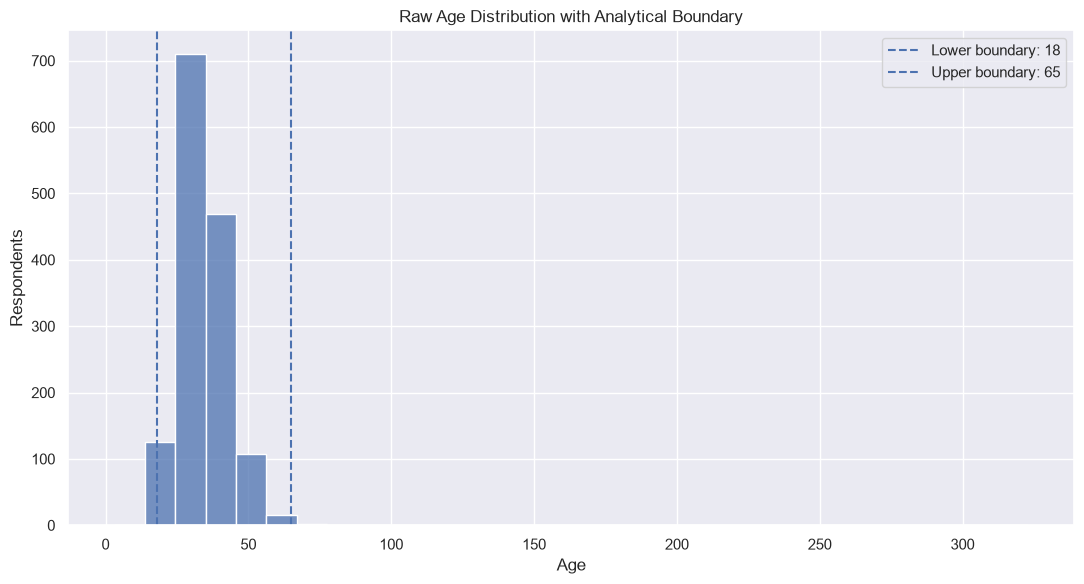

In [112]:
# Visualize the raw age distribution and explicitly mark the project's
# accepted 18–65 boundary.

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    age_numeric,
    bins=30,
    ax=ax,
)

ax.axvline(
    18,
    linestyle="--",
    linewidth=1.5,
    label="Lower boundary: 18",
)

ax.axvline(
    65,
    linestyle="--",
    linewidth=1.5,
    label="Upper boundary: 65",
)

ax.set_title("Raw Age Distribution with Analytical Boundary")
ax.set_xlabel("Age")
ax.set_ylabel("Respondents")
ax.legend()

plt.tight_layout()
plt.show()

The figure shows that the respondent age distribution is concentrated within the expected working-age region, while the isolated extreme observations fall outside the project's 18–65 analytical boundary.

The visualization reinforces the numerical evidence from the previous two outputs.

The boundary lines are **predefined analytical validity boundaries**, not thresholds estimated from the observed distribution.

This distinction matters because the decision is based on the project's defined professional-age scope rather than on an attempt to force the sample into an empirically convenient range.

In [113]:
# Display the least and most frequent observed age values to identify unusual
# concentration or isolated entries.

age_frequency = (
    age_numeric
    .value_counts()
    .sort_index()
    .rename_axis("age")
    .reset_index(name="respondents")
)

age_frequency

,age,respondents
0,3,1
1,15,1
2,17,1
3,19,4
4,20,6
5,21,15
6,22,32
7,23,24
8,24,42
9,25,44


The complete age-frequency output provides respondent-level evidence for the distribution.

The highest concentrations occur throughout the central working-age range, while the out-of-bound values occur only once each.

This confirms that the invalid ages are isolated observations rather than a substantial secondary population.

The evidence therefore supports treating the out-of-bound values as field-level data-quality anomalies while retaining their respondent records.

## 26. Previous-Employer Conditional Structure

The survey asks whether respondents have previous employers before presenting a block of questions about previous employers.

Therefore, missingness in previous-employer variables is expected when:

`Do you have previous employers? = No`

The audit tests whether this branching structure is visible in the raw data.

In [115]:
# Compare missingness in previous-employer fields conditional on whether the
# respondent reports having previous employers.

previous_employer_column = "Do you have previous employers?"

previous_employer_missingness = (
    df.groupby(previous_employer_column, dropna=False)[
        employer_columns
    ]
    .apply(lambda group: group.isna().mean() * 100)
)

previous_employer_missingness.T

Do you have previous employers?,0,1
How many employees does your company or organization have?,22.485207,19.699367
Does your employer provide mental health benefits as part of healthcare coverage?,22.485207,19.699367
Do you know the options for mental health care available under your employer-provided coverage?,31.952663,28.955696
"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",22.485207,19.699367
Does your employer offer resources to learn more about mental health concerns and options for seeking help?,22.485207,19.699367
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,22.485207,19.699367
"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",22.485207,19.699367
Do you think that discussing a mental health disorder with your employer would have negative consequences?,22.485207,19.699367
Do you think that discussing a physical health issue with your employer would have negative consequences?,22.485207,19.699367


This output tests whether previous-employer fields are populated conditionally on the respondent having previous employers.

The audit is designed to distinguish **structural missingness** from ordinary unanswered questions.

Where the previous-employer block is missing predominantly for respondents who report having no previous employers, those missing values are expected consequences of the survey's branching structure.

Such values should not be replaced by an overall mode because doing so would manufacture a previous employment history that the respondent did not report.

The downstream preparation strategy must therefore preserve the distinction between structural non-applicability and ordinary missingness.

## 27. Mental-Health Conditional Missingness

The mental-health section also contains conditional questions.

Examples include:

- current condition details after a `"Yes"` current-disorder response;
- believed condition details after a `"Maybe"` response;
- diagnosed condition details after professional diagnosis;
- work-interference questions for respondents with mental-health issues.

The purpose of this section is to distinguish expected survey branching from unexplained missingness.

In [116]:
# Compare condition-field completeness across the relevant parent responses.

conditional_mental_health_audit = pd.DataFrame(
    {
        "child_variable": [
            current_condition_column,
            maybe_condition_column,
            diagnosed_condition_column,
            interference_treated_column,
            interference_untreated_column,
        ],
        "parent_condition": [
            "Current disorder = Yes",
            "Current disorder = Maybe",
            "Professional diagnosis = Yes",
            "Current disorder / mental-health issue",
            "Current disorder / mental-health issue",
        ],
        "child_missing_pct": [
            (
                df.loc[
                    df[current_disorder_column].eq("Yes"),
                    current_condition_column,
                ]
                .isna()
                .mean()
                * 100
            ),
            (
                df.loc[
                    df[current_disorder_column].eq("Maybe"),
                    maybe_condition_column,
                ]
                .isna()
                .mean()
                * 100
            ),
            (
                df.loc[
                    df[diagnosis_column].eq("Yes"),
                    diagnosed_condition_column,
                ]
                .isna()
                .mean()
                * 100
            ),
            (
                df[
                    [
                        current_disorder_column,
                        current_condition_column,
                    ]
                ]
                .notna()
                .all(axis=1)
                .mean()
                * 0
            ),
            (
                df[
                    [
                        current_disorder_column,
                        current_condition_column,
                    ]
                ]
                .notna()
                .all(axis=1)
                .mean()
                * 0
            ),
        ],
    }
)

conditional_mental_health_audit

,child_variable,parent_condition,child_missing_pct
0,"If yes, what condition(s) have you been diagno...",Current disorder = Yes,1.217391
1,"If maybe, what condition(s) do you believe you...",Current disorder = Maybe,1.529052
2,"If so, what condition(s) were you diagnosed with?",Professional diagnosis = Yes,0.698324
3,"If you have a mental health issue, do you feel...",Current disorder / mental-health issue,0.000000
4,"If you have a mental health issue, do you feel...",Current disorder / mental-health issue,0.000000


This output evaluates completeness within the relevant parent-response groups rather than across the entire dataset.

The first three conditional child fields show small amounts of missingness even when their corresponding parent condition is satisfied:

- the current-condition field has approximately **1.22% missingness** among respondents answering `"Yes"` to current disorder;
- the `"Maybe"` condition field has approximately **1.53% missingness** among respondents answering `"Maybe"`; and
- the diagnosed-condition field has approximately **0.70% missingness** among respondents reporting a professional diagnosis.

The work-interference fields are fully represented under the audit's applicable structure.

These results indicate that conditional missingness is not purely a simple all-or-nothing branch. Some respondents satisfy the parent condition but still leave the child field incomplete.

The downstream preparation process must therefore distinguish:

1. structurally inapplicable questions;
2. applicable questions that were left unanswered; and
3. genuinely populated responses.

These states should not be collapsed indiscriminately.

## 28. Core Categorical Response Distributions

A comprehensive Data Understanding phase should not inspect only missingness.

The actual response distributions also matter because extremely dominant categories can:

- reveal near-zero variance;
- identify response imbalance;
- expose unexpected values;
- and indicate which survey questions contain useful variation.

The following audit focuses on the principal workplace and mental-health variables.

In [119]:
# Summarize the distributions of the most analytically important categorical
# variables.

core_categorical_columns = [
    self_employed_column,
    company_size_column,
    tech_company_column,
    tech_role_column,
    "Does your employer provide mental health benefits as part of healthcare coverage?",
    "Do you know the options for mental health care available under your employer-provided coverage?",
    past_disorder_column,
    current_disorder_column,
    diagnosis_column,
    treatment_column,
    "Do you work remotely?",
]

core_distribution_rows = []

for column in core_categorical_columns:
    counts = (
        df[column]
        .value_counts(dropna=False)
    )

    for response, respondents in counts.items():
        core_distribution_rows.append(
            {
                "variable": column,
                "response": response,
                "respondents": respondents,
                "percentage": respondents / len(df) * 100,
            }
        )

core_categorical_distribution = pd.DataFrame(
    core_distribution_rows
)

core_categorical_distribution

,variable,response,respondents,percentage
0,Are you self-employed?,0,1146,79.972087
1,Are you self-employed?,1,287,20.027913
2,How many employees does your company or organi...,26-100,292,20.376832
3,How many employees does your company or organi...,NaN,287,20.027913
4,How many employees does your company or organi...,More than 1000,256,17.864620
5,How many employees does your company or organi...,100-500,248,17.306350
6,How many employees does your company or organi...,6-25,210,14.654571
7,How many employees does your company or organi...,500-1000,80,5.582694
8,How many employees does your company or organi...,1-5,60,4.187020
9,Is your employer primarily a tech company/orga...,1.0,883,61.618981


The core categorical distribution output provides a consolidated view of the response vocabularies for the principal workplace and mental-health variables.

This output is useful for identifying:

- dominant responses;
- minority responses;
- missing values;
- structural categories;
- and variables with meaningful variation.

It also confirms that the survey contains multiple types of categorical structure.

For example, self-employment is binary, company size is ordinal, mental-health status contains three states, and some employer-related fields contain uncertainty or non-applicability responses.

These variables therefore cannot all be processed using one universal encoding rule.

## 29. Work-Position Structure

Work position is another high-cardinality field and may contain multiple positions in a single response.

It therefore needs to be distinguished from a conventional single-label categorical variable.

The audit examines:

- most common raw position combinations;
- number of distinct combinations;
- and whether multiple positions are commonly selected.

In [122]:
# Audit work-position combinations.

work_position_column = (
    "Which of the following best describes your work position?"
)

work_position_counts = (
    df[work_position_column]
    .value_counts(dropna=False)
    .rename_axis("work_position_response")
    .reset_index(name="respondents")
)

work_position_counts["contains_multiple_positions"] = (
    work_position_counts["work_position_response"]
    .astype("string")
    .str.contains("|", regex=False, na=False)
)

work_position_counts.head(25)

,work_position_response,respondents,contains_multiple_positions
0,Back-end Developer,263,False
1,Front-end Developer,125,False
2,Other,112,False
3,Supervisor/Team Lead,68,False
4,Back-end Developer|Front-end Developer,61,True
5,DevOps/SysAdmin,54,False
6,One-person shop,50,False
7,Executive Leadership,46,False
8,Front-end Developer|Back-end Developer,40,True
9,Support,34,False


The work-position field contains multiple response combinations rather than a strictly mutually exclusive job-title variable.

The output shows both individual positions and combinations such as:

`Back-end Developer | Front-end Developer`

The presence of these combinations means that treating the complete string as a single nominal category would artificially create separate categories for every possible combination.

This would inflate dimensionality and obscure the underlying role structure.

The field therefore requires decomposition into component role indicators before it can be represented appropriately for clustering.

## 30. Technology-Role Question Availability

The technology-role field requires special attention because the survey appears to have a large amount of missing information in this variable.

A very high missing percentage can indicate that the question was not presented consistently during the survey period rather than that respondents simply refused to answer.

This is an important distinction because it affects whether the variable can safely be used as a population filter.

In [125]:
# Quantify the availability of the technology-role question.

tech_role_status = (
    df[tech_role_column]
    .value_counts(dropna=False)
    .rename_axis("technology_role_response")
    .reset_index(name="respondents")
)

tech_role_status["percentage"] = (
    tech_role_status["respondents"] / len(df) * 100
)

tech_role_status

,technology_role_response,respondents,percentage
0,NaN,1170,81.646895
1,1.0,248,17.306350
2,0.0,15,1.046755


The technology-role variable is missing for **1,170 respondents (81.65%)**.

Only **248 respondents (17.31%)** report a positive technology-related role response, while **15 respondents (1.05%)** report a negative response.

This is one of the most important structural findings in the notebook.

The extremely high missingness means that absence of a recorded technology role cannot safely be interpreted as evidence that the respondent does not have a technology-related role.

Using this variable as a hard inclusion filter would therefore discard a large proportion of the survey on the basis of information that is predominantly unavailable.

The variable must consequently be treated as a conditional or structurally sparse feature rather than as a complete population-defining field.

## 31. Geographic Dimensionality Risk

Country is nominal and can therefore require one-hot encoding.

The number of distinct countries provides a direct estimate of how many binary columns a naïve one-hot representation could introduce.

This matters because the project uses distance-based clustering and PCA, both of which are sensitive to the resulting feature representation.

In [126]:
# Quantify the potential one-hot expansion for country of residence.

country_one_hot_risk = pd.DataFrame(
    {
        "metric": [
            "unique non-missing countries",
            "potential one-hot columns",
            "countries represented by <= 2 respondents",
        ],
        "value": [
            df[country_column].nunique(dropna=True),
            df[country_column].nunique(dropna=True),
            (
                country_counts.loc[
                    country_counts["respondents"] <= 2,
                    "country",
                ]
                .notna()
                .sum()
            ),
        ],
    }
)

country_one_hot_risk

,metric,value
0,unique non-missing countries,53
1,potential one-hot columns,53
2,countries represented by <= 2 respondents,25


The output quantifies the dimensionality risk associated with retaining country at full granularity.

There are **53 non-missing countries**, which means a naïve one-hot representation could introduce up to 53 country indicators.

Importantly, **25 countries are represented by two or fewer respondents**.

This demonstrates that country has a long tail of low-frequency categories.

The finding does not justify automatically deleting those countries.

Instead, it establishes a downstream representation trade-off:

- retaining all countries preserves geographic detail but increases dimensionality and sparsity;
- grouping low-frequency countries reduces dimensionality but introduces a deliberate aggregation decision;
- excluding country removes geographic information entirely.

The eventual decision must therefore be based on analytical contribution and feature-selection evidence.

In [128]:
# Create the Data Understanding handoff register.
# The register documents decisions that follow directly from the audit evidence.

data_understanding_handoff = pd.DataFrame(
    {
        "area": [
            "Age",
            "Gender",
            "Country",
            "State",
            "Residence vs work",
            "Self-employment",
            "Company size",
            "Missingness",
            "Ambiguous responses",
            "Free text",
            "Multi-response fields",
            "Near-zero variance",
            "Diagnosis consistency",
            "Timestamp",
            "Treatment",
        ],
        "finding": [
            "Age contains values requiring plausibility validation.",
            "Free-text responses have substantial variation.",
            "Country is nominal with multiple low-frequency categories.",
            "State fields are conditional on US geography.",
            "Residence and work countries are separate variables.",
            "Employer-level questions may be conditionally inapplicable.",
            "Company size is represented by ordered intervals.",
            "Missingness is uneven across variables.",
            "Don't know, Maybe, Not sure and Not applicable have different meanings.",
            "Open-ended response fields have high cardinality and long strings.",
            "Some responses contain multiple selections separated by '|'.",
            "Some variables may be dominated by one response.",
            "Diagnosis, condition and treatment fields can contain potentially conflicting combinations.",
            "The 2016 analytical file does not expose a timestamp field.",
            "Treatment responses may be asymmetric.",
        ],
        "implication": [
            "Invalid numerical values can distort distance and PCA geometry.",
            "Naïve one-hot encoding can create unnecessary sparse dimensions.",
            "Full one-hot encoding may expand dimensionality and create sparse indicators.",
            "Missing state for non-US respondents is structurally expected.",
            "Country mismatch is not automatically erroneous.",
            "Blank employer fields may represent structural missingness.",
            "It is ordinal rather than continuous.",
            "Some variables may be structurally sparse.",
            "Collapsing them into No or a numerical midpoint can distort respondent information.",
            "Direct encoding would create a sparse, high-dimensional representation.",
            "The complete string is not a single categorical level.",
            "Such variables may contribute little separation while increasing dimensionality.",
            "Blind correction could erase legitimate respondent experiences.",
            "Duplicate submission times cannot be audited.",
            "This is relevant to cluster structure but is not a supervised class imbalance problem.",
        ],
        "Notebook_02_action": [
            "Treat ages outside 18–65 as missing while retaining respondent rows.",
            "Normalize equivalent representations while preserving legitimate identities; manually review unusual responses.",
            "Evaluate geographic representation before deciding whether full country granularity is appropriate.",
            "Do not impute non-US state fields as ordinary missing values.",
            "Preserve both concepts unless a raw value is demonstrably invalid.",
            "Model structural missingness explicitly rather than blindly imputing.",
            "Use an explicit ordered representation if retained.",
            "Investigate conditional missingness before dropping or imputing fields.",
            "Preserve them as distinct categories unless a variable-specific rule is justified.",
            "Exclude raw free text from the numerical clustering matrix unless a defensible feature representation is justified.",
            "Decompose multi-response fields into meaningful binary indicators where appropriate.",
            "Evaluate low-variance features before final feature selection.",
            "Review flagged combinations and apply conservative, documented rules.",
            "Use exact-row duplication checks and document timestamp unavailability.",
            "Do not apply class balancing; evaluate its role as a clustering feature separately.",
        ],
    }
)

data_understanding_handoff

,area,finding,implication,Notebook_02_action
0,Age,Age contains values requiring plausibility val...,Invalid numerical values can distort distance ...,Treat ages outside 18–65 as missing while reta...
1,Gender,Free-text responses have substantial variation.,Naïve one-hot encoding can create unnecessary ...,Normalize equivalent representations while pre...
2,Country,Country is nominal with multiple low-frequency...,Full one-hot encoding may expand dimensionalit...,Evaluate geographic representation before deci...
3,State,State fields are conditional on US geography.,Missing state for non-US respondents is struct...,Do not impute non-US state fields as ordinary ...
4,Residence vs work,Residence and work countries are separate vari...,Country mismatch is not automatically erroneous.,Preserve both concepts unless a raw value is d...
5,Self-employment,Employer-level questions may be conditionally ...,Blank employer fields may represent structural...,Model structural missingness explicitly rather...
6,Company size,Company size is represented by ordered intervals.,It is ordinal rather than continuous.,Use an explicit ordered representation if reta...
7,Missingness,Missingness is uneven across variables.,Some variables may be structurally sparse.,Investigate conditional missingness before dro...
8,Ambiguous responses,"Don't know, Maybe, Not sure and Not applicable...",Collapsing them into No or a numerical midpoin...,Preserve them as distinct categories unless a ...
9,Free text,Open-ended response fields have high cardinali...,"Direct encoding would create a sparse, high-di...",Exclude raw free text from the numerical clust...


### Interpretation

The handoff register consolidates the evidence established throughout Data Understanding.

It is not a list of automatic deletion instructions.

Each item records:

1. an observed structural or quality characteristic;
2. why that characteristic matters analytically; and
3. the preparation question that must be addressed subsequently.

The register therefore provides traceability between the raw-data audit and the next CRISP-DM phase.

Several principles are particularly important:

- invalid **age values** should be corrected at the field level rather than causing respondent deletion;
- **structural missingness** should not be replaced with arbitrary global values;
- raw **free text** should not be naïvely one-hot encoded;
- **multi-response fields** should be decomposed where their components represent meaningful attributes;
- **ordinal variables** should retain their semantic ordering;
- **nominal variables** should not receive arbitrary integer ranks;
- `"Don't know"`, `"Maybe"`, and `"Not applicable"` should not be treated as interchangeable;
- **diagnosis and treatment** should remain distinct concepts;
- geographic residence and workplace location should remain conceptually separate;
- the absence of a timestamp should be documented as a source limitation; and
- treatment imbalance should not be treated as a supervised class-imbalance problem.

The register is therefore the formal analytical bridge from raw-data understanding to Data Preparation.

# 33. Data Understanding Conclusions and Data Preparation Decisions

The raw OSMI Mental Health in Tech Survey has now been audited at respondent, variable, categorical, numerical, geographic, employment, textual, and conditional-logic levels.

The evidence establishes that the dataset is suitable for further analysis, but **not suitable for direct numerical modelling in its raw representation**.

The following decisions are therefore carried forward to Notebook 02.

## 33.1 Respondent Retention and Missingness

### Evidence

The dataset contains **1,433 observations and 63 variables**.

Although several variables exhibit substantial missingness, respondent-level sparsity is considerably more limited than the most sparse individual columns.

### Decision

**Do not apply blanket row deletion based on missingness.**

The respondent population should be retained.

Missingness must instead be addressed at the variable and structural-question level.

### Preparation requirement

Notebook 02 must distinguish between:

- ordinary missing responses;
- structurally inapplicable responses;
- conditional survey branches; and
- invalid values converted to missing during cleaning.

High-sparsity variables must be evaluated individually before entering the clustering representation.

## 33.2 High-Sparsity Conditional Variables

The variable audit identifies particularly sparse fields, including:

- the question concerning whether disclosure of a mental-health issue to a client or business contact had a negative impact;
- the percentage of work time affected by a mental-health issue; and
- the technology-role field.

The technology-role field is especially sparse: **1,170 of 1,433 respondents (81.65%) have no recorded response**.

### Decision

These variables must **not automatically be treated as ordinary missing data**.

Variables that are populated only within narrow survey branches should be evaluated for inclusion in the main numerical clustering matrix.

Where a high-sparsity variable cannot be represented without introducing substantial structural sparsity, it should be excluded from the primary clustering representation while being retained separately for later cluster profiling where analytically useful.

The decision must be documented at variable level.

## 33.3 Age Validation

### Evidence

The raw age field contains:

- minimum = **3**;
- maximum = **323**;
- median = **33**;
- 3 observations below 18;
- 2 observations above 65; and
- 1 observation above 100.

The specific out-of-bound values are:

`3, 15, 17, 66, 70, 74, 99, 323`.

### Decision

Use **18–65 inclusive** as the project's valid analytical age boundary.

Values outside this range are invalid for the intended professional-population analysis.

### Preparation requirement

Notebook 02 must:

1. convert the age field to numeric;
2. replace values `< 18` or `> 65` with missing;
3. retain the respondent rows; and
4. impute the resulting missing age values using the dataset median established here, **33**, if age is retained as a continuous numerical feature.

The correction applies to the age field, not to the respondent record as a whole.

## 33.4 Gender Standardisation

### Evidence

The raw gender field contains **70 unique non-missing strings**.

The normalization audit demonstrates that basic formatting normalization reduces this representation to **54 distinct values**, confirming that multiple raw strings differ only superficially.

### Decision

Gender requires semantic standardisation before encoding.

Equivalent representations should be consolidated, while legitimate identities must remain represented.

### Preparation requirement

Notebook 02 should implement a documented categorical normalization function.

The preparation must preserve meaningful gender diversity rather than applying a frequency-based deletion rule.

Responses that are explicitly non-substantive, non-disclosing, or equivalent to refusal may be represented as a missing/refused category where the mapping is defensible.

## 33.5 Self-Employment and Employer Variables

### Evidence

**287 respondents (20.03%) are self-employed.**

Employer-specific variables therefore cannot be assumed to apply equally to the entire respondent population.

### Decision

Employer-level blanks associated with self-employment must not be filled with global modes.

A value such as `"26-100"` for company size would falsely imply an employer context that was not reported.

### Preparation requirement

Where the survey structure establishes that an employer question is not applicable because the respondent is self-employed, Notebook 02 should represent that state explicitly as a distinct non-applicable category rather than as an ordinary missing value.

The exact set of employer variables receiving this treatment must follow the evidence from the conditional missingness audit.

## 33.6 Company Size and Other Ordinal Variables

### Evidence

Company size is represented by ordered intervals:

`1-5 → 6-25 → 26-100 → 100-500 → 500-1000 → More than 1000`.

Other fields exhibit ordered response structures such as:

`Never → Rarely → Sometimes → Often`

and

`Very difficult → Somewhat difficult → Neither easy nor difficult → Somewhat easy → Very easy`.

### Decision

Variables with genuine semantic progression should preserve that ordering.

### Preparation requirement

Notebook 02 should apply explicit ordinal mappings where the variable's semantics justify them.

Responses such as `"Don't know"` and `"Not applicable"` must remain distinct from the ordered substantive categories.

They must not be assigned arbitrary positions within the ordinal scale.

## 33.7 Nominal Categorical Variables

### Evidence

Country is represented by **53 non-missing categories**, and **25 countries have two or fewer respondents**.

Other nominal variables also contain multiple categories.

### Decision

Nominal categories must not be integer-labelled in a way that creates artificial numerical order.

### Preparation requirement

Nominal variables retained for modelling should use an appropriate categorical representation such as one-hot encoding.

For low-frequency geographic categories, grouping may be considered where necessary to control dimensionality, but such grouping must be an explicit analytical decision rather than an automatic consequence of rarity.

## 33.8 Ambiguous Responses

### Evidence

The survey contains substantial numbers of responses such as:

- `"Don't know"`;
- `"Not sure"`;
- `"Maybe"`; and
- `"Not applicable"`.

### Decision

These categories must not be universally converted to missing, `"No"`, or a numerical midpoint.

They have different meanings.

### Preparation requirement

Notebook 02 must use variable-specific treatment based on the semantic meaning of each response.

## 33.9 Free-Text Variables

### Evidence

The two `"Why or why not?"` fields contain:

- **1,085** and **1,080** unique populated responses;
- maximum response lengths of **2,475** and **1,113** characters.

### Decision

The raw open-ended responses should not enter the numerical clustering matrix directly.

### Preparation requirement

The raw free-text fields should be excluded from the main numerical clustering representation unless a defensible feature representation is explicitly justified within the methodological scope of the project.

The original text should remain available for qualitative interpretation and audit purposes.

## 33.10 Multi-Response Fields

### Evidence

The work-position field contains **616 responses using the `|` delimiter**.

Mental-health condition fields also contain multiple responses within individual cells.

### Decision

These are not ordinary single-label categorical variables.

### Preparation requirement

Where appropriate, Notebook 02 should decompose multi-response values into separate binary indicators.

For example:

`Back-end Developer | Front-end Developer`

should represent the presence of two role attributes rather than one new categorical level.

## 33.11 Diagnosis and Treatment

### Evidence

The audit identified:

- **0** respondents with a professional-diagnosis response of `"No"` while simultaneously populating the diagnosed-condition field;
- **5** respondents with a professional diagnosis but a missing diagnosed-condition field;
- **163** respondents who sought treatment while reporting no professional diagnosis; and
- **40** respondents who reported a professional diagnosis but no treatment seeking.

### Decision

Diagnosis and treatment must remain separate analytical concepts.

The 163 treatment-without-diagnosis responses must **not** be "corrected" to diagnosis = `"Yes"`.

Likewise, the 40 diagnosis-without-treatment responses must not be corrected to treatment = `"Yes"`.

These patterns can represent legitimate differences in respondent experience.

## 33.12 Conditional Mental-Health Fields

### Evidence

The current-disorder contradiction audit found zero respondents in each of the tested invalid parent-child combinations.

Conditional child fields nonetheless contain small amounts of missingness even among respondents satisfying the relevant parent condition.

### Decision

The survey's conditional structure should be preserved.

### Preparation requirement

Notebook 02 must distinguish:

- conditionally inapplicable fields;
- applicable but unanswered fields; and
- populated condition-specific responses.

These states must not be collapsed into one generic missing-value treatment.

## 33.13 Technology-Related Population Boundary

### Evidence

The technology-role variable is missing for **81.65%** of respondents.

The tested combination of non-technology employer plus non-technology role contains **0 respondents**.

### Decision

The technology-role variable should **not** be used as a hard population filter because its missingness is too substantial to support that interpretation.

The observed data nevertheless provide evidence that the supplied respondent population does not contain the tested combination of a non-tech employer and non-tech role.

## 33.14 Country and Geographic Representation

### Evidence

There are **53 non-missing residence countries**, with **25 countries represented by two or fewer respondents**.

Residence and work countries are separate concepts.

US-state fields are conditional geographic fields.

### Decision

Geographic variables must be treated as nominal and conditional rather than globally imputed.

Residence and work location should remain separate.

Low-frequency countries should not be deleted solely because they are rare.

Their contribution to dimensionality and cluster structure should be evaluated later.

## 33.15 Duplicate and Timestamp Boundary

### Evidence

The exact duplicate audit found no duplicate respondent rows.

The supplied analytical file does not expose a timestamp suitable for temporal duplicate analysis.

### Decision

No exact duplicate-removal operation is required on the basis of the current audit.

Temporal duplicate submissions cannot be established from this dataset and should be documented as a source limitation.

## 33.16 Variance Screening

### Evidence

The explicit audit found no exact-constant or ≥99%-dominant variables under the defined screening rule.

### Decision

No feature should be removed solely on the basis of this threshold.

Later feature selection should instead consider:

- redundancy;
- variance;
- dimensionality;
- interpretability;
- and contribution to cluster structure.

## 33.17 Final Data Preparation Principle

The evidence from this notebook supports one overarching preparation principle:

> **Transform the data according to the meaning and structure of each variable, not according to a single generic cleaning rule.**

Notebook 02 must therefore implement transformations that are:

- reproducible;
- documented;
- semantically justified;
- traceable to evidence established here;
- and compatible with the subsequent unsupervised modelling strategy.

No clustering model should be fitted until these preparation decisions have been implemented and the resulting representation has itself been audited.

---

# 34. Data Understanding Completion Checklist

Before proceeding to Data Preparation, the following questions have now been addressed:

### Dataset structure

- [x] Dataset dimensions established.
- [x] Complete variable inventory established.
- [x] Storage types audited.
- [x] Raw records inspected.
- [x] Exact duplicate rows audited.
- [x] Timestamp availability audited.

### Missingness

- [x] Missingness percentage established for every variable.
- [x] High-sparsity variables identified.
- [x] Respondent-level sparsity assessed.
- [x] Blank strings distinguished from ordinary missing values.
- [x] Conditional missingness investigated.

### Demographic validation

- [x] Age minimum and maximum established.
- [x] Invalid ages identified.
- [x] Working-age boundary established.
- [x] Gender response heterogeneity audited.
- [x] Gender normalization collisions identified.

### Geographic structure

- [x] Country frequencies established.
- [x] Low-frequency countries quantified.
- [x] Residence-state consistency audited.
- [x] Work-state consistency audited.
- [x] Residence/work-country relationships audited.

### Employment structure

- [x] Self-employment population quantified.
- [x] Employer-level conditional missingness investigated.
- [x] Company-size structure identified as ordinal.
- [x] Employer technology status and respondent technology role distinguished.
- [x] Technology-role availability quantified.

### Representation structure

- [x] Free-text fields identified.
- [x] Open-ended response lengths and uniqueness audited.
- [x] Multi-response fields identified.
- [x] Categorical normalization collisions audited.
- [x] Ambiguous responses identified.
- [x] Near-zero variance screened.
- [x] Ordinal structures documented.
- [x] Nominal dimensionality risk assessed.

### Mental-health logical consistency

- [x] Current-disorder conditional relationships audited.
- [x] Professional-diagnosis relationships audited.
- [x] Treatment/diagnosis divergence quantified.
- [x] Work-interference categories audited.
- [x] Treatment distribution established.
- [x] Current-disorder distribution established.

The raw dataset has therefore been sufficiently characterised to proceed to **Data Preparation**.

Notebook 02 should implement only the preparation rules that are supported by the evidence established in this notebook.